# EXP 02.1 — Fair Rebuild untuk History Branch: Lite vs Full History, Freeze Raw-Output Tuning, dan Recursive Approx Screening

---

## Ringkasan Eksperimen

Notebook ini adalah **rebuild yang lebih fair** untuk branch history dari EXP 02. Fokusnya bukan menambah kompleksitas baru, tetapi membersihkan cara evaluasi history branch agar perbandingan antar-variant menjadi lebih jujur dan mudah diinterpretasikan.

Eksperimen ini membandingkan lima variant utama:

1. **control_static**
2. **lite_freeze**
3. **full_freeze**
4. **lite_recursive_approx**
5. **full_recursive_approx**

Prinsip utamanya ada tiga:

- **freeze harus raw-output-first**, jadi decoder dituning dari raw outputs yang digenerate sekali,
- **recursive post-hoc tuning harus dilabeli approximate**, bukan faithful,
- **semua variant harus apple-to-apple**: split sama, evaluator sama, scoreline prior sama, dan grid decoder sama.

Metrik utama tetap **offline AW-MAE**.


## 01. Setup, Seed, Path, dan Warning Eksperimen


In [1]:

import os
import json
import math
import copy
import random
import warnings
from pathlib import Path
from collections import Counter, deque
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm
from catboost import CatBoostRegressor, CatBoostClassifier, Pool
from sklearn.metrics import accuracy_score, mean_absolute_error

print("[INFO] Semua library berhasil di-import.")


[INFO] Semua library berhasil di-import.


In [2]:

# === KONFIGURASI GLOBAL ===
SEED = 42

TRAIN_PATH = "../data/train.csv"
TEST_PATH = "../data/test.csv"
SAMPLE_SUB_PATH = "../data/sample submission.csv"
META_PATH = "../data/metadata.txt"

OUTPUT_ROOT = Path("../outputs/exp02_1_history_engine_repair_fair_validation")
FIG_DIR = OUTPUT_ROOT / "figures"
PRED_DIR = OUTPUT_ROOT / "predictions"
SUB_DIR = OUTPUT_ROOT / "submissions"
SUM_DIR = OUTPUT_ROOT / "summaries"

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
pd.set_option("display.max_rows", 200)
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

print(f"[INFO] SEED = {SEED}")
print(f"[INFO] TRAIN = {TRAIN_PATH}")
print(f"[INFO] TEST = {TEST_PATH}")
print(f"[INFO] SAMPLE = {SAMPLE_SUB_PATH}")
print(f"[INFO] META = {META_PATH}")


[INFO] SEED = 42
[INFO] TRAIN = ../data/train.csv
[INFO] TEST = ../data/test.csv
[INFO] SAMPLE = ../data/sample submission.csv
[INFO] META = ../data/metadata.txt


In [3]:

def seed_everything(seed: int = 42) -> None:
    """Set seed dasar untuk reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"[INFO] Seed set to {seed}")


seed_everything(SEED)

for d in [FIG_DIR, PRED_DIR, SUB_DIR, SUM_DIR]:
    d.mkdir(parents=True, exist_ok=True)
    print(f"[OK] {d}")


[INFO] Seed set to 42
[OK] ..\outputs\exp02_1_history_engine_repair_fair_validation\figures
[OK] ..\outputs\exp02_1_history_engine_repair_fair_validation\predictions
[OK] ..\outputs\exp02_1_history_engine_repair_fair_validation\submissions
[OK] ..\outputs\exp02_1_history_engine_repair_fair_validation\summaries


### Warning eksperimen

- **Freeze** harus memakai pola **raw-output-first**. Jangan rerun full simulation untuk setiap kombinasi decoder.
- **Recursive approx** di notebook ini memang **approximate**, karena trajectory raw outputs dibangun sekali lalu decoder dituning post-hoc.
- **Recursive faithful** tidak dijalankan di notebook ini, karena runtime cost-nya besar dan bukan fokus utama EXP 02.1.
- Untuk history models, early stopping harus memakai regime yang **fair**, yaitu inner temporal split di dalam `train_fold`, bukan valid horizon utama yang seharusnya tetap bersih.


## 02. Validasi File Input


In [4]:

FILE_PATHS = {
    "train": TRAIN_PATH,
    "test": TEST_PATH,
    "sample_submission": SAMPLE_SUB_PATH,
    "metadata": META_PATH,
}


def validate_input_files(file_paths: dict) -> None:
    """Validasi file input dan raise error dengan pesan jelas jika ada yang hilang."""
    missing = []
    for name, path in file_paths.items():
        if not Path(path).exists():
            missing.append((name, path))
    if missing:
        lines = [f"- {name}: {path}" for name, path in missing]
        raise FileNotFoundError(
            "File input tidak ditemukan:\n" + "\n".join(lines)
        )
    print("[OK] Semua file input ditemukan.")


validate_input_files(FILE_PATHS)


[OK] Semua file input ditemukan.


## 03. Load Data dan Helper Dasar


In [5]:

train = pd.read_csv(TRAIN_PATH, parse_dates=["date"])
test = pd.read_csv(TEST_PATH, parse_dates=["date"])
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)

with open(META_PATH, "r", encoding="utf-8") as fp:
    metadata_text = fp.read()

print(f"[INFO] train shape       : {train.shape}")
print(f"[INFO] test shape        : {test.shape}")
print(f"[INFO] sample_sub shape  : {sample_sub.shape}")
print(f"[INFO] metadata length   : {len(metadata_text)} chars")
display(train.head(2))
display(test.head(2))
display(sample_sub.head(2))


[INFO] train shape       : (78772, 47)
[INFO] test shape        : (42422, 20)
[INFO] sample_sub shape  : (42422, 3)
[INFO] metadata length   : 1829 chars


,Id,match_id,date,gender,team,opponent,is_home,neutral,tournament,venue_country,team_goals,opp_goals,team_points_last5,opp_points_last5,points_last5_diff,team_gd_last5,opp_gd_last5,gd_last5_diff,h2h_points_last5,h2h_gd_last5,days_since_last_match_team,days_since_last_match_opp,team_points_last10,opp_points_last10,team_avg_goals_last5,team_avg_conceded_last5,opp_avg_goals_last5,opp_avg_conceded_last5,team_win_rate_last10,opp_win_rate_last10,elo_team,elo_opponent,rank_team,rank_opponent,rank_diff,rank_missing_team,rank_missing_opp,confederation_team,confederation_opp,population_team,population_opp,gdp_per_capita_team,gdp_per_capita_opp,altitude_venue,distance_travel_team,distance_travel_opp,temperature_venue
0,M000001_Scotland,M000001,1872-11-30,M,Scotland,England,1,0,Friendly,Scotland,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1500.0,1500.0,NaN,NaN,NaN,1,1,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,M000001_England,M000001,1872-11-30,M,England,Scotland,0,0,Friendly,Scotland,0,0,NaN,1.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,1.0,NaN,NaN,0.0,0.0,NaN,0.0,1500.0,1500.0,NaN,NaN,NaN,1,1,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Id,match_id,date,gender,team,opponent,is_home,neutral,tournament,venue_country,confederation_team,confederation_opp,population_team,population_opp,gdp_per_capita_team,gdp_per_capita_opp,altitude_venue,distance_travel_team,distance_travel_opp,temperature_venue
0,M034984_Seychelles,M034984,2011-08-06,M,Seychelles,Mauritius,1,0,Indian Ocean Island Games,Seychelles,CAF,CAF,92409.0,1283330.0,12189.095160,9197.026972,-9999.0,0.000000,1751.895724,25.790169
1,M034984_Mauritius,M034984,2011-08-06,M,Mauritius,Seychelles,0,0,Indian Ocean Island Games,Seychelles,CAF,CAF,1283330.0,92409.0,9197.026972,12189.095160,-9999.0,1751.895724,0.000000,25.790169


,Id,team_goals,opp_goals
0,M034984_Seychelles,0,0
1,M034984_Mauritius,0,0


In [6]:

# ============================================================
# HELPER FUNCTIONS — standalone dari EXP 00 / EXP 01 / EXP 02
# ============================================================

EXACT_PENALTY = 0.30
OUTCOME_PENALTY = 0.25
GD_PENALTY = 0.15
WRONG_OUTCOME_MULTIPLIER = 1.50
NONLINEAR_POWER = 1.50


def build_match_level(df: pd.DataFrame, is_train: bool) -> pd.DataFrame:
    """Konversi row-level ke match-level canonical.

    Canonical rule: team_a = alfabet pertama dalam satu match_id.
    Tujuannya agar representasi stabil dan reversible.
    """
    required = ["match_id", "team", "date"]
    for col in required:
        if col not in df.columns:
            raise KeyError(f"Kolom wajib tidak ditemukan: {col}")

    counts = df.groupby("match_id").size()
    bad = counts[counts != 2]
    if len(bad) > 0:
        raise ValueError(f"Ditemukan {len(bad)} match_id tanpa tepat dua row.")

    sort_cols = [c for c in ["match_id", "team", "Id"] if c in df.columns]
    temp = df.sort_values(sort_cols).reset_index(drop=True)

    row_a = temp.groupby("match_id", sort=False).nth(0).reset_index()
    row_b = temp.groupby("match_id", sort=False).nth(1).reset_index()

    if not (row_a["match_id"].values == row_b["match_id"].values).all():
        raise AssertionError("Pairing match-level gagal: urutan match_id tidak sinkron.")

    result = pd.DataFrame()
    scalar_cols = [
        "match_id", "date", "gender", "tournament", "venue_country", "neutral",
        "altitude_venue", "temperature_venue",
    ]
    for col in scalar_cols:
        if col in temp.columns:
            result[col] = row_a[col].values

    result["team_a"] = row_a["team"].astype(str).values
    result["team_b"] = row_b["team"].astype(str).values

    if "is_home" in temp.columns:
        result["team_a_is_home"] = row_a["is_home"].fillna(0).astype(float).values
        result["team_b_is_home"] = row_b["is_home"].fillna(0).astype(float).values
    else:
        result["team_a_is_home"] = 0.0
        result["team_b_is_home"] = 0.0

    side_map = {
        "confederation_team": "confederation",
        "population_team": "population",
        "gdp_per_capita_team": "gdp_per_capita",
        "distance_travel_team": "distance_travel",
    }
    for raw_col, suffix in side_map.items():
        if raw_col in temp.columns:
            result[f"team_a_{suffix}"] = row_a[raw_col].values
            result[f"team_b_{suffix}"] = row_b[raw_col].values
        else:
            result[f"team_a_{suffix}"] = np.nan
            result[f"team_b_{suffix}"] = np.nan

    if is_train:
        if "team_goals" not in temp.columns or "opp_goals" not in temp.columns:
            raise KeyError("Target team_goals/opp_goals tidak ditemukan di train.")
        result["team_a_goals"] = row_a["team_goals"].astype(float).values
        result["team_b_goals"] = row_a["opp_goals"].astype(float).values

    return result


def match_predictions_to_submission(
    test_row_df: pd.DataFrame,
    pred_match_df: pd.DataFrame,
    canonical_team_a_col: str = "team_a",
    canonical_team_b_col: str = "team_b",
    pred_a_col: str = "pred_team_a_goals",
    pred_b_col: str = "pred_team_b_goals",
) -> pd.DataFrame:
    """Konversi prediksi match-level ke format submission row-level."""
    need_cols = ["match_id", canonical_team_a_col, canonical_team_b_col, pred_a_col, pred_b_col]
    missing = [c for c in need_cols if c not in pred_match_df.columns]
    if missing:
        raise KeyError(f"Kolom pred_match_df belum lengkap: {missing}")

    tmp = test_row_df[["Id", "match_id", "team"]].copy()
    merged = tmp.merge(pred_match_df[need_cols], on="match_id", how="left")
    is_a = merged["team"].astype(str) == merged[canonical_team_a_col].astype(str)
    merged["team_goals"] = np.where(is_a, merged[pred_a_col], merged[pred_b_col])
    merged["opp_goals"] = np.where(is_a, merged[pred_b_col], merged[pred_a_col])
    return merged[["Id", "team_goals", "opp_goals"]].copy()


def _outcome(a: int, b: int) -> int:
    if a > b:
        return 1
    if a == b:
        return 0
    return -1


def get_tournament_weight(tournament: str) -> float:
    t = str(tournament).lower().strip()
    if "fifa world cup" in t or t == "world cup":
        return 2.00
    if "afc championship" in t or "afc asian cup" in t or "asian cup" in t:
        return 1.80
    if "friendly" in t:
        return 0.96
    return 1.20


def official_match_loss(y_team_true: int, y_opp_true: int, y_team_pred: int, y_opp_pred: int) -> float:
    yt, yo = int(y_team_true), int(y_opp_true)
    pt, po = int(y_team_pred), int(y_opp_pred)
    mae = (abs(yt - pt) + abs(yo - po)) / 2.0

    exact = int((yt == pt) and (yo == po))
    outcome = int(_outcome(yt, yo) == _outcome(pt, po))
    gd = int((yt - yo) == (pt - po))

    penalty = (
        EXACT_PENALTY * (1 - exact)
        + OUTCOME_PENALTY * (1 - outcome)
        + GD_PENALTY * (1 - gd)
    )
    multiplier = 1.0 if outcome else WRONG_OUTCOME_MULTIPLIER
    raw_loss = mae + penalty
    return float((raw_loss * multiplier) ** NONLINEAR_POWER)


def awmae_score(y_team_true, y_opp_true, y_team_pred, y_opp_pred, tournaments) -> float:
    yt = np.asarray(y_team_true)
    yo = np.asarray(y_opp_true)
    pt = np.asarray(y_team_pred)
    po = np.asarray(y_opp_pred)
    tw = np.asarray([get_tournament_weight(x) for x in tournaments], dtype=float)

    losses = np.array([
        official_match_loss(a, b, c, d)
        for a, b, c, d in zip(yt, yo, pt, po)
    ], dtype=float)
    return float(np.sum(losses * tw) / np.sum(tw))


def make_time_based_holdout(train_match: pd.DataFrame, valid_fraction: float = 0.2):
    """Temporal holdout leakage-safe di level match."""
    if not 0 < valid_fraction < 1:
        raise ValueError("valid_fraction harus berada di antara 0 dan 1.")

    temp = train_match.sort_values(["date", "match_id"]).reset_index(drop=True)
    n_valid = max(1, int(math.ceil(len(temp) * valid_fraction)))
    split_idx = len(temp) - n_valid
    train_fold = temp.iloc[:split_idx].copy().reset_index(drop=True)
    valid_fold = temp.iloc[split_idx:].copy().reset_index(drop=True)
    if train_fold["match_id"].isin(valid_fold["match_id"]).any():
        raise AssertionError("Leakage: match_id overlap antara train_fold dan valid_fold.")
    return train_fold, valid_fold


print("[OK] Helper dasar siap dipakai.")


[OK] Helper dasar siap dipakai.


### Catatan helper dasar

Notebook ini tetap **self-contained**. Helper dari eksperimen sebelumnya dibawa ulang agar seluruh pipeline bisa dijalankan dari nol tanpa bergantung pada state notebook lain.


## 04. Cleaning Awal dan Canonical Match Data


In [7]:

# Cleaning konservatif
for df_name, df in [("train", train), ("test", test)]:
    if "altitude_venue" in df.columns:
        mask = df["altitude_venue"].eq(-9999)
        n = int(mask.sum())
        if n > 0:
            df.loc[mask, "altitude_venue"] = np.nan
            print(f"[INFO] {df_name}: altitude_venue == -9999 diubah ke NaN sebanyak {n} row")

    string_cols = [
        "team", "opponent", "gender", "tournament", "venue_country",
        "confederation_team", "confederation_opp",
    ]
    for col in string_cols:
        if col in df.columns:
            df[col] = df[col].fillna("UNKNOWN").astype(str)

    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    if df["date"].isna().any():
        raise ValueError(f"{df_name} memiliki date yang gagal diparse.")

train_match_base = build_match_level(train, is_train=True)
test_match_base = build_match_level(test, is_train=False)

print(f"[INFO] train_match_base shape : {train_match_base.shape}")
print(f"[INFO] test_match_base shape  : {test_match_base.shape}")
display(train_match_base.head(3))


[INFO] train: altitude_venue == -9999 diubah ke NaN sebanyak 766 row
[INFO] test: altitude_venue == -9999 diubah ke NaN sebanyak 296 row
[INFO] train_match_base shape : (39386, 22)
[INFO] test_match_base shape  : (21211, 20)


,match_id,date,gender,tournament,venue_country,neutral,altitude_venue,temperature_venue,team_a,team_b,team_a_is_home,team_b_is_home,team_a_confederation,team_b_confederation,team_a_population,team_b_population,team_a_gdp_per_capita,team_b_gdp_per_capita,team_a_distance_travel,team_b_distance_travel,team_a_goals,team_b_goals
0,M000001,1872-11-30,M,Friendly,Scotland,0,NaN,NaN,England,Scotland,0.0,1.0,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1,M000002,1873-03-08,M,Friendly,England,0,NaN,NaN,England,Scotland,1.0,0.0,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,4.0,2.0
2,M000003,1874-03-07,M,Friendly,Scotland,0,NaN,NaN,England,Scotland,0.0,1.0,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0


Canonicalization tetap dibuat **identik** dengan eksperimen sebelumnya: `team_a` dan `team_b` ditentukan secara deterministik berdasarkan urutan alfabetis. Ini penting agar comparison antar-eksperimen tetap konsisten.


## 05. Static Feature Block


In [8]:

def _safe_ratio(a: pd.Series, b: pd.Series) -> pd.Series:
    a = pd.to_numeric(a, errors="coerce")
    b = pd.to_numeric(b, errors="coerce")
    out = pd.Series(np.where((b == 0) | b.isna(), np.nan, a / b), index=a.index)
    out = out.replace([np.inf, -np.inf], np.nan)
    return out


def engineer_static_match_features(df_match: pd.DataFrame) -> pd.DataFrame:
    """Bangun block static features yang konsisten dengan control EXP 01."""
    df = df_match.copy()
    dt = pd.to_datetime(df["date"])

    # Date features
    df["match_year"] = dt.dt.year
    df["match_month"] = dt.dt.month
    df["match_quarter"] = dt.dt.quarter
    df["match_dayofweek"] = dt.dt.dayofweek
    df["match_dayofyear"] = dt.dt.dayofyear
    df["match_is_weekend"] = (dt.dt.dayofweek >= 5).astype(int)
    df["match_decade"] = (dt.dt.year // 10) * 10

    # Venue / home / tournament features
    df["home_side"] = np.where(
        df["team_a_is_home"].fillna(0).astype(float) > 0, 1,
        np.where(df["team_b_is_home"].fillna(0).astype(float) > 0, -1, 0),
    )
    conf_a = df["team_a_confederation"].fillna("UNKNOWN").astype(str)
    conf_b = df["team_b_confederation"].fillna("UNKNOWN").astype(str)
    df["same_confederation"] = (conf_a == conf_b).astype(int)

    tournament_low = df["tournament"].fillna("").astype(str).str.lower()
    df["is_friendly"] = tournament_low.str.contains("friendly").astype(int)
    df["is_world_cup"] = tournament_low.str.contains("world cup").astype(int)
    df["is_qualification"] = tournament_low.str.contains("qualif").astype(int)
    df["is_nations_league"] = tournament_low.str.contains("nations league").astype(int)
    df["tournament_weight_proxy"] = df["tournament"].apply(get_tournament_weight)

    # Numeric symmetry-aware features
    pairs = [
        ("population", "team_a_population", "team_b_population"),
        ("gdp", "team_a_gdp_per_capita", "team_b_gdp_per_capita"),
        ("distance", "team_a_distance_travel", "team_b_distance_travel"),
    ]
    for prefix, col_a, col_b in pairs:
        a = pd.to_numeric(df[col_a], errors="coerce")
        b = pd.to_numeric(df[col_b], errors="coerce")
        df[f"{prefix}_a"] = a
        df[f"{prefix}_b"] = b
        df[f"{prefix}_diff"] = a - b
        df[f"{prefix}_abs_diff"] = (a - b).abs()
        df[f"log_{prefix}_a"] = np.log1p(a.clip(lower=0))
        df[f"log_{prefix}_b"] = np.log1p(b.clip(lower=0))
        df[f"log_{prefix}_diff"] = df[f"log_{prefix}_a"] - df[f"log_{prefix}_b"]
        df[f"{prefix}_ratio_ab"] = _safe_ratio(a, b)

    # Matchup categories
    df["pair_key"] = df["team_a"].astype(str) + "__VS__" + df["team_b"].astype(str)
    df["confed_pair_key"] = conf_a + "__VS__" + conf_b

    return df


train_static_df = engineer_static_match_features(train_match_base)
test_static_df = engineer_static_match_features(test_match_base)

print(f"[INFO] train_static_df shape : {train_static_df.shape}")
print(f"[INFO] test_static_df shape  : {test_static_df.shape}")
display(train_static_df.head(2))


[INFO] train_static_df shape : (39386, 62)
[INFO] test_static_df shape  : (21211, 60)


,match_id,date,gender,tournament,venue_country,neutral,altitude_venue,temperature_venue,team_a,team_b,team_a_is_home,team_b_is_home,team_a_confederation,team_b_confederation,team_a_population,team_b_population,team_a_gdp_per_capita,team_b_gdp_per_capita,team_a_distance_travel,team_b_distance_travel,team_a_goals,team_b_goals,match_year,match_month,match_quarter,match_dayofweek,match_dayofyear,match_is_weekend,match_decade,home_side,same_confederation,is_friendly,is_world_cup,is_qualification,is_nations_league,tournament_weight_proxy,population_a,population_b,population_diff,population_abs_diff,log_population_a,log_population_b,log_population_diff,population_ratio_ab,gdp_a,gdp_b,gdp_diff,gdp_abs_diff,log_gdp_a,log_gdp_b,log_gdp_diff,gdp_ratio_ab,distance_a,distance_b,distance_diff,distance_abs_diff,log_distance_a,log_distance_b,log_distance_diff,distance_ratio_ab,pair_key,confed_pair_key
0,M000001,1872-11-30,M,Friendly,Scotland,0,NaN,NaN,England,Scotland,0.0,1.0,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1872,11,4,5,335,1,1870,-1,1,1,0,0,0,0.96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,England__VS__Scotland,UEFA__VS__UEFA
1,M000002,1873-03-08,M,Friendly,England,0,NaN,NaN,England,Scotland,1.0,0.0,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,4.0,2.0,1873,3,1,5,67,1,1870,1,1,1,0,0,0,0.96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,England__VS__Scotland,UEFA__VS__UEFA


Static feature block ini menjadi **control block** yang sengaja dijaga tetap mirip dengan EXP 01. Dengan begitu, perbandingan `control_static` vs history branch tetap adil.


## 06. Historical State Engine


In [9]:

# ============================================================
# STATE INITIALIZATION
# ============================================================
K_ELO = 24.0
K_GD = 6.0
ELO_HOME_BONUS = 60.0
GD_HOME_BONUS = 10.0
EWMA_ALPHA = 0.35


def init_team_state() -> dict:
    return {
        "matches_played": 0,
        "last_match_date": pd.NaT,
        "elo_overall": 1500.0,
        "elo_goal_diff": 0.0,
        "ewm_points": 1.0,
        "ewm_goals_for": 1.2,
        "ewm_goals_against": 1.2,
        "ewm_goal_diff": 0.0,
        "recent_points_5": deque(maxlen=5),
        "recent_points_10": deque(maxlen=10),
        "recent_gf_5": deque(maxlen=5),
        "recent_ga_5": deque(maxlen=5),
        "recent_gd_5": deque(maxlen=5),
        "recent_results_10": deque(maxlen=10),
        "recent_clean_sheet_5": deque(maxlen=5),
        "recent_failed_to_score_5": deque(maxlen=5),
    }


def init_h2h_state() -> dict:
    return {
        "h2h_matches_played": 0,
        "h2h_points_a_last3": deque(maxlen=3),
        "h2h_gd_a_last3": deque(maxlen=3),
        "h2h_total_goals_last3": deque(maxlen=3),
    }


def expected_elo_result(rating_a: float, rating_b: float, home_bonus: float = 0.0) -> float:
    return 1.0 / (1.0 + 10 ** (-(rating_a + home_bonus - rating_b) / 400.0))


def _deque_mean(dq, default=np.nan):
    return float(sum(dq) / len(dq)) if len(dq) > 0 else default


print("[OK] History state definitions siap.")


[OK] History state definitions siap.


In [10]:

def snapshot_team_features_lite(state: dict, match_date: pd.Timestamp) -> dict:
    """Snapshot sederhana untuk mode history-lite."""
    last_date = state.get("last_match_date", pd.NaT)
    if pd.isna(last_date):
        days_since = np.nan
    else:
        days_since = float((pd.Timestamp(match_date) - pd.Timestamp(last_date)).days)

    return {
        "hist_matches_played": float(state["matches_played"]),
        "hist_elo_overall": float(state["elo_overall"]),
        "hist_ewm_points": float(state["ewm_points"]),
        "hist_ewm_gf": float(state["ewm_goals_for"]),
        "hist_ewm_ga": float(state["ewm_goals_against"]),
        "hist_days_since_last_match": days_since,
        "hist_has_history": float(state["matches_played"] > 0),
    }


def snapshot_team_features_full(state: dict, match_date: pd.Timestamp) -> dict:
    """Snapshot lengkap untuk mode history-full."""
    base = snapshot_team_features_lite(state, match_date)
    base.update({
        "hist_elo_gd": float(state["elo_goal_diff"]),
        "hist_ewm_gd": float(state["ewm_goal_diff"]),
        "hist_points_avg_last5": _deque_mean(state["recent_points_5"]),
        "hist_points_avg_last10": _deque_mean(state["recent_points_10"]),
        "hist_gf_avg_last5": _deque_mean(state["recent_gf_5"]),
        "hist_ga_avg_last5": _deque_mean(state["recent_ga_5"]),
        "hist_gd_avg_last5": _deque_mean(state["recent_gd_5"]),
        "hist_win_rate_last10": _deque_mean([1.0 if x == 1.0 else 0.0 for x in state["recent_results_10"]]),
        "hist_draw_rate_last10": _deque_mean([1.0 if x == 0.5 else 0.0 for x in state["recent_results_10"]]),
        "hist_loss_rate_last10": _deque_mean([1.0 if x == 0.0 else 0.0 for x in state["recent_results_10"]]),
        "hist_clean_sheet_rate_last5": _deque_mean(state["recent_clean_sheet_5"]),
        "hist_failed_to_score_rate_last5": _deque_mean(state["recent_failed_to_score_5"]),
    })
    return base


def snapshot_h2h_features(state: dict) -> dict:
    return {
        "h2h_matches_played_pre": float(state["h2h_matches_played"]),
        "h2h_points_a_avg_last3": _deque_mean(state["h2h_points_a_last3"]),
        "h2h_gd_a_avg_last3": _deque_mean(state["h2h_gd_a_last3"]),
        "h2h_total_goals_avg_last3": _deque_mean(state["h2h_total_goals_last3"]),
        "h2h_has_history": float(state["h2h_matches_played"] > 0),
    }


def update_states_from_score(
    state_a: dict,
    state_b: dict,
    h2h_state: dict,
    match_context: dict,
    goals_a: int,
    goals_b: int,
):
    """Update team state + H2H state in-place berdasarkan score integer."""
    goals_a = int(goals_a)
    goals_b = int(goals_b)
    goal_diff = goals_a - goals_b

    if goals_a > goals_b:
        points_a, points_b = 3, 0
        result_a, result_b = 1.0, 0.0
    elif goals_a == goals_b:
        points_a, points_b = 1, 1
        result_a, result_b = 0.5, 0.5
    else:
        points_a, points_b = 0, 3
        result_a, result_b = 0.0, 1.0

    tournament_w = get_tournament_weight(match_context.get("tournament", ""))
    home_a = float(match_context.get("home_a", 0))
    home_b = float(match_context.get("home_b", 0))
    elo_home_bonus = ELO_HOME_BONUS * home_a - ELO_HOME_BONUS * home_b
    gd_home_bonus = GD_HOME_BONUS * home_a - GD_HOME_BONUS * home_b

    exp_a = expected_elo_result(state_a["elo_overall"], state_b["elo_overall"], elo_home_bonus)
    exp_gd_a = (state_a["elo_goal_diff"] + gd_home_bonus - state_b["elo_goal_diff"]) / 100.0
    resid_gd_a = goal_diff - exp_gd_a

    state_a["elo_overall"] += K_ELO * tournament_w * (result_a - exp_a)
    state_b["elo_overall"] -= K_ELO * tournament_w * (result_a - exp_a)
    state_a["elo_goal_diff"] += K_GD * resid_gd_a
    state_b["elo_goal_diff"] -= K_GD * resid_gd_a

    for st, pts, gf, ga, gd, res in [
        (state_a, points_a, goals_a, goals_b, goal_diff, result_a),
        (state_b, points_b, goals_b, goals_a, -goal_diff, result_b),
    ]:
        st["matches_played"] += 1
        st["ewm_points"] = EWMA_ALPHA * pts + (1 - EWMA_ALPHA) * st["ewm_points"]
        st["ewm_goals_for"] = EWMA_ALPHA * gf + (1 - EWMA_ALPHA) * st["ewm_goals_for"]
        st["ewm_goals_against"] = EWMA_ALPHA * ga + (1 - EWMA_ALPHA) * st["ewm_goals_against"]
        st["ewm_goal_diff"] = EWMA_ALPHA * gd + (1 - EWMA_ALPHA) * st["ewm_goal_diff"]
        st["recent_points_5"].append(float(pts))
        st["recent_points_10"].append(float(pts))
        st["recent_gf_5"].append(float(gf))
        st["recent_ga_5"].append(float(ga))
        st["recent_gd_5"].append(float(gd))
        st["recent_results_10"].append(float(res))
        st["recent_clean_sheet_5"].append(float(ga == 0))
        st["recent_failed_to_score_5"].append(float(gf == 0))
        st["last_match_date"] = pd.Timestamp(match_context["date"])

    h2h_state["h2h_matches_played"] += 1
    h2h_state["h2h_points_a_last3"].append(float(points_a))
    h2h_state["h2h_gd_a_last3"].append(float(goal_diff))
    h2h_state["h2h_total_goals_last3"].append(float(goals_a + goals_b))

    return state_a, state_b, h2h_state


print("[OK] Snapshot dan update function siap.")


[OK] Snapshot dan update function siap.


### Catatan state engine

- Team state disimpan per key **`(gender, team)`** agar men’s dan women’s branch tidak bercampur.
- H2H disimpan ringan di key **`(gender, team_a, team_b)`** dari perspektif canonical side A.
- Untuk train, history harus **benar-benar pre-match**: snapshot dulu, baru update state dengan hasil aktual.


## 07. Build Train Pre-Match Historical Features


In [11]:

def build_history_feature_row(
    match_row: pd.Series,
    team_states: dict,
    h2h_states: dict,
    feature_mode: str,
) -> dict:
    gender = str(match_row["gender"])
    team_a = str(match_row["team_a"])
    team_b = str(match_row["team_b"])
    key_a = (gender, team_a)
    key_b = (gender, team_b)
    key_h2h = (gender, team_a, team_b)

    state_a = team_states.setdefault(key_a, init_team_state())
    state_b = team_states.setdefault(key_b, init_team_state())
    h2h_state = h2h_states.setdefault(key_h2h, init_h2h_state())

    if feature_mode == "lite":
        snap_a = snapshot_team_features_lite(state_a, match_row["date"])
        snap_b = snapshot_team_features_lite(state_b, match_row["date"])
    elif feature_mode == "full":
        snap_a = snapshot_team_features_full(state_a, match_row["date"])
        snap_b = snapshot_team_features_full(state_b, match_row["date"])
    else:
        raise ValueError("feature_mode harus 'lite' atau 'full'.")

    row = {"match_id": match_row["match_id"]}
    for k, v in snap_a.items():
        row[f"{k}_a"] = v
    for k, v in snap_b.items():
        row[f"{k}_b"] = v

    # delta features
    row["hist_matches_played_diff"] = row["hist_matches_played_a"] - row["hist_matches_played_b"]
    row["hist_elo_overall_diff"] = row["hist_elo_overall_a"] - row["hist_elo_overall_b"]
    row["hist_ewm_points_diff"] = row["hist_ewm_points_a"] - row["hist_ewm_points_b"]
    row["hist_ewm_gf_diff"] = row["hist_ewm_gf_a"] - row["hist_ewm_gf_b"]
    row["hist_ewm_ga_diff"] = row["hist_ewm_ga_a"] - row["hist_ewm_ga_b"]
    row["hist_rest_days_diff"] = row["hist_days_since_last_match_a"] - row["hist_days_since_last_match_b"]

    if feature_mode == "full":
        row["hist_elo_gd_diff"] = row["hist_elo_gd_a"] - row["hist_elo_gd_b"]
        row["hist_elo_gd_abs_diff"] = abs(row["hist_elo_gd_diff"])
        row["hist_elo_overall_abs_diff"] = abs(row["hist_elo_overall_diff"])
        row["hist_ewm_gd_diff"] = row["hist_ewm_gd_a"] - row["hist_ewm_gd_b"]
        row["hist_points_avg_last5_diff"] = row["hist_points_avg_last5_a"] - row["hist_points_avg_last5_b"]
        row["hist_points_avg_last10_diff"] = row["hist_points_avg_last10_a"] - row["hist_points_avg_last10_b"]
        row["hist_gf_avg_last5_diff"] = row["hist_gf_avg_last5_a"] - row["hist_gf_avg_last5_b"]
        row["hist_ga_avg_last5_diff"] = row["hist_ga_avg_last5_a"] - row["hist_ga_avg_last5_b"]
        row["hist_gd_avg_last5_diff"] = row["hist_gd_avg_last5_a"] - row["hist_gd_avg_last5_b"]
        row["hist_win_rate_last10_diff"] = row["hist_win_rate_last10_a"] - row["hist_win_rate_last10_b"]
        row["hist_draw_rate_last10_diff"] = row["hist_draw_rate_last10_a"] - row["hist_draw_rate_last10_b"]
        row["hist_loss_rate_last10_diff"] = row["hist_loss_rate_last10_a"] - row["hist_loss_rate_last10_b"]
        row["hist_clean_sheet_rate_last5_diff"] = row["hist_clean_sheet_rate_last5_a"] - row["hist_clean_sheet_rate_last5_b"]
        row["hist_failed_to_score_rate_last5_diff"] = row["hist_failed_to_score_rate_last5_a"] - row["hist_failed_to_score_rate_last5_b"]

    row.update(snapshot_h2h_features(h2h_state))
    return row


def build_train_history_features(train_match_df: pd.DataFrame, feature_mode: str):
    """Bangun history features train secara leakage-safe.

    Urutan wajib:
    1) sort by date
    2) snapshot pre-match
    3) simpan row history
    4) update actual states
    """
    temp = train_match_df.sort_values(["date", "match_id"]).reset_index(drop=True)
    team_states = {}
    h2h_states = {}
    rows = []

    for _, row in tqdm(temp.iterrows(), total=len(temp), desc=f"build_train_history[{feature_mode}]"):
        hist_row = build_history_feature_row(row, team_states, h2h_states, feature_mode)
        rows.append(hist_row)

        gender = str(row["gender"])
        team_a = str(row["team_a"])
        team_b = str(row["team_b"])
        key_a = (gender, team_a)
        key_b = (gender, team_b)
        key_h2h = (gender, team_a, team_b)

        context = {
            "date": row["date"],
            "tournament": row["tournament"],
            "home_a": row.get("team_a_is_home", 0),
            "home_b": row.get("team_b_is_home", 0),
        }
        update_states_from_score(
            team_states[key_a],
            team_states[key_b],
            h2h_states[key_h2h],
            context,
            int(row["team_a_goals"]),
            int(row["team_b_goals"]),
        )

    hist_df = pd.DataFrame(rows)
    return hist_df, team_states, h2h_states


train_history_lite_df, _, _ = build_train_history_features(train_match_base, feature_mode="lite")
train_history_full_df, _, _ = build_train_history_features(train_match_base, feature_mode="full")

print(f"[INFO] train_history_lite_df shape : {train_history_lite_df.shape}")
print(f"[INFO] train_history_full_df shape : {train_history_full_df.shape}")
display(train_history_lite_df.head(2))
display(train_history_full_df.head(2))


build_train_history[lite]:   0%|          | 0/39386 [00:00<?, ?it/s]

build_train_history[full]:   0%|          | 0/39386 [00:00<?, ?it/s]

[INFO] train_history_lite_df shape : (39386, 26)
[INFO] train_history_full_df shape : (39386, 64)


,match_id,hist_matches_played_a,hist_elo_overall_a,hist_ewm_points_a,hist_ewm_gf_a,hist_ewm_ga_a,hist_days_since_last_match_a,hist_has_history_a,hist_matches_played_b,hist_elo_overall_b,hist_ewm_points_b,hist_ewm_gf_b,hist_ewm_ga_b,hist_days_since_last_match_b,hist_has_history_b,hist_matches_played_diff,hist_elo_overall_diff,hist_ewm_points_diff,hist_ewm_gf_diff,hist_ewm_ga_diff,hist_rest_days_diff,h2h_matches_played_pre,h2h_points_a_avg_last3,h2h_gd_a_avg_last3,h2h_total_goals_avg_last3,h2h_has_history
0,M000001,0.0,1500.00000,1.0,1.20,1.20,NaN,0.0,0.0,1500.00000,1.0,1.20,1.20,NaN,0.0,0.0,0.000000,0.0,0.0,0.0,NaN,0.0,NaN,NaN,NaN,0.0
1,M000002,1.0,1501.96989,1.0,0.78,0.78,98.0,1.0,1.0,1498.03011,1.0,0.78,0.78,98.0,1.0,0.0,3.939779,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0


,match_id,hist_matches_played_a,hist_elo_overall_a,hist_ewm_points_a,hist_ewm_gf_a,hist_ewm_ga_a,hist_days_since_last_match_a,hist_has_history_a,hist_elo_gd_a,hist_ewm_gd_a,hist_points_avg_last5_a,hist_points_avg_last10_a,hist_gf_avg_last5_a,hist_ga_avg_last5_a,hist_gd_avg_last5_a,hist_win_rate_last10_a,hist_draw_rate_last10_a,hist_loss_rate_last10_a,hist_clean_sheet_rate_last5_a,hist_failed_to_score_rate_last5_a,hist_matches_played_b,hist_elo_overall_b,hist_ewm_points_b,hist_ewm_gf_b,hist_ewm_ga_b,hist_days_since_last_match_b,hist_has_history_b,hist_elo_gd_b,hist_ewm_gd_b,hist_points_avg_last5_b,hist_points_avg_last10_b,hist_gf_avg_last5_b,hist_ga_avg_last5_b,hist_gd_avg_last5_b,hist_win_rate_last10_b,hist_draw_rate_last10_b,hist_loss_rate_last10_b,hist_clean_sheet_rate_last5_b,hist_failed_to_score_rate_last5_b,hist_matches_played_diff,hist_elo_overall_diff,hist_ewm_points_diff,hist_ewm_gf_diff,hist_ewm_ga_diff,hist_rest_days_diff,hist_elo_gd_diff,hist_elo_gd_abs_diff,hist_elo_overall_abs_diff,hist_ewm_gd_diff,hist_points_avg_last5_diff,hist_points_avg_last10_diff,hist_gf_avg_last5_diff,hist_ga_avg_last5_diff,hist_gd_avg_last5_diff,hist_win_rate_last10_diff,hist_draw_rate_last10_diff,hist_loss_rate_last10_diff,hist_clean_sheet_rate_last5_diff,hist_failed_to_score_rate_last5_diff,h2h_matches_played_pre,h2h_points_a_avg_last3,h2h_gd_a_avg_last3,h2h_total_goals_avg_last3,h2h_has_history
0,M000001,0.0,1500.00000,1.0,1.20,1.20,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1500.00000,1.0,1.20,1.20,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.000000,0.0,0.0,0.0,NaN,0.0,0.0,0.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0
1,M000002,1.0,1501.96989,1.0,0.78,0.78,98.0,1.0,0.6,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1498.03011,1.0,0.78,0.78,98.0,1.0,-0.6,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,3.939779,0.0,0.0,0.0,0.0,1.2,1.2,3.939779,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0


History-lite sengaja dibuat lebih sederhana. Tujuannya untuk menguji apakah masalah di EXP 02 berasal dari **state full yang terlalu noisy**, bukan dari ide history itu sendiri.


## 08. Temporal Holdout dan Cutoff State


In [12]:

train_fold_base, valid_fold_base = make_time_based_holdout(train_match_base, valid_fraction=0.2)

print(f"[INFO] train_fold_base shape : {train_fold_base.shape}")
print(f"[INFO] valid_fold_base shape : {valid_fold_base.shape}")
print(f"[INFO] train range : {train_fold_base['date'].min()} -> {train_fold_base['date'].max()}")
print(f"[INFO] valid range : {valid_fold_base['date'].min()} -> {valid_fold_base['date'].max()}")
print(f"[INFO] overlap match_id = {train_fold_base['match_id'].isin(valid_fold_base['match_id']).sum()}")


[INFO] train_fold_base shape : (31508, 22)
[INFO] valid_fold_base shape : (7878, 22)
[INFO] train range : 1872-11-30 00:00:00 -> 2005-01-30 00:00:00
[INFO] valid range : 2005-02-01 00:00:00 -> 2011-08-04 00:00:00
[INFO] overlap match_id = 0


In [13]:

# History khusus train_fold untuk menyiapkan cutoff state validation
train_fold_hist_lite, cutoff_team_states_valid_lite, cutoff_h2h_states_valid_lite = build_train_history_features(
    train_fold_base, feature_mode="lite"
)
train_fold_hist_full, cutoff_team_states_valid_full, cutoff_h2h_states_valid_full = build_train_history_features(
    train_fold_base, feature_mode="full"
)

train_fold_lite = train_fold_base.merge(train_fold_hist_lite, on="match_id", how="left")
train_fold_full = train_fold_base.merge(train_fold_hist_full, on="match_id", how="left")

print(f"[INFO] train_fold_lite shape : {train_fold_lite.shape}")
print(f"[INFO] train_fold_full shape : {train_fold_full.shape}")


build_train_history[lite]:   0%|          | 0/31508 [00:00<?, ?it/s]

build_train_history[full]:   0%|          | 0/31508 [00:00<?, ?it/s]

[INFO] train_fold_lite shape : (31508, 47)
[INFO] train_fold_full shape : (31508, 85)


Validation horizon harus mulai dari **cutoff state akhir `train_fold`**. Setelah titik ini, inference history untuk validation **tidak boleh** memakai actual valid outcomes.


## 09. Definisi Final Feature Sets


In [14]:

# Static categorical & numeric
static_categorical_features = [
    "team_a", "team_b", "gender", "tournament", "venue_country",
    "team_a_confederation", "team_b_confederation", "pair_key", "confed_pair_key",
]

static_numeric_features = [
    "match_year", "match_month", "match_quarter", "match_dayofweek", "match_dayofyear",
    "match_is_weekend", "match_decade", "team_a_is_home", "team_b_is_home", "neutral",
    "home_side", "same_confederation", "is_friendly", "is_world_cup", "is_qualification",
    "is_nations_league", "tournament_weight_proxy", "altitude_venue", "temperature_venue",
    "population_a", "population_b", "population_diff", "population_abs_diff",
    "log_population_a", "log_population_b", "log_population_diff", "population_ratio_ab",
    "gdp_a", "gdp_b", "gdp_diff", "gdp_abs_diff", "log_gdp_a", "log_gdp_b",
    "log_gdp_diff", "gdp_ratio_ab", "distance_a", "distance_b", "distance_diff",
    "distance_abs_diff", "log_distance_a", "log_distance_b", "log_distance_diff",
    "distance_ratio_ab",
]

history_lite_numeric_features = [
    "hist_matches_played_a", "hist_matches_played_b",
    "hist_elo_overall_a", "hist_elo_overall_b",
    "hist_ewm_points_a", "hist_ewm_points_b",
    "hist_ewm_gf_a", "hist_ewm_gf_b",
    "hist_ewm_ga_a", "hist_ewm_ga_b",
    "hist_days_since_last_match_a", "hist_days_since_last_match_b",
    "hist_has_history_a", "hist_has_history_b",
    "hist_matches_played_diff", "hist_elo_overall_diff", "hist_ewm_points_diff",
    "hist_ewm_gf_diff", "hist_ewm_ga_diff", "hist_rest_days_diff",
    "h2h_matches_played_pre", "h2h_points_a_avg_last3", "h2h_gd_a_avg_last3",
    "h2h_total_goals_avg_last3", "h2h_has_history",
]

history_full_numeric_features = history_lite_numeric_features + [
    "hist_elo_gd_a", "hist_elo_gd_b", "hist_ewm_gd_a", "hist_ewm_gd_b",
    "hist_points_avg_last5_a", "hist_points_avg_last5_b",
    "hist_points_avg_last10_a", "hist_points_avg_last10_b",
    "hist_gf_avg_last5_a", "hist_gf_avg_last5_b",
    "hist_ga_avg_last5_a", "hist_ga_avg_last5_b",
    "hist_gd_avg_last5_a", "hist_gd_avg_last5_b",
    "hist_win_rate_last10_a", "hist_win_rate_last10_b",
    "hist_draw_rate_last10_a", "hist_draw_rate_last10_b",
    "hist_loss_rate_last10_a", "hist_loss_rate_last10_b",
    "hist_clean_sheet_rate_last5_a", "hist_clean_sheet_rate_last5_b",
    "hist_failed_to_score_rate_last5_a", "hist_failed_to_score_rate_last5_b",
    "hist_elo_gd_diff", "hist_elo_gd_abs_diff", "hist_elo_overall_abs_diff",
    "hist_ewm_gd_diff", "hist_points_avg_last5_diff", "hist_points_avg_last10_diff",
    "hist_gf_avg_last5_diff", "hist_ga_avg_last5_diff", "hist_gd_avg_last5_diff",
    "hist_win_rate_last10_diff", "hist_draw_rate_last10_diff", "hist_loss_rate_last10_diff",
    "hist_clean_sheet_rate_last5_diff", "hist_failed_to_score_rate_last5_diff",
]

control_features = static_categorical_features + static_numeric_features
lite_features = control_features + history_lite_numeric_features
full_features = control_features + history_full_numeric_features

with open(SUM_DIR / "feature_columns.json", "w", encoding="utf-8") as fp:
    json.dump({
        "static_categorical_features": static_categorical_features,
        "static_numeric_features": static_numeric_features,
        "control_features": control_features,
    }, fp, indent=2)

with open(SUM_DIR / "history_lite_feature_columns.json", "w", encoding="utf-8") as fp:
    json.dump(history_lite_numeric_features, fp, indent=2)

with open(SUM_DIR / "history_full_feature_columns.json", "w", encoding="utf-8") as fp:
    json.dump(history_full_numeric_features, fp, indent=2)

print(f"[OK] feature_columns.json disimpan.")
print(f"[INFO] #control_features = {len(control_features)}")
print(f"[INFO] #lite_features    = {len(lite_features)}")
print(f"[INFO] #full_features    = {len(full_features)}")


[OK] feature_columns.json disimpan.
[INFO] #control_features = 52
[INFO] #lite_features    = 77
[INFO] #full_features    = 115


Di EXP 02.1 ini, comparison utamanya bukan hanya **history vs no-history**, tetapi juga **history-lite vs history-full**. Tujuannya melihat apakah block history sederhana justru lebih stabil dibanding versi full yang lebih padat.


## 10. Target Construction


In [15]:

def build_outcome_target(goal_a: pd.Series, goal_b: pd.Series) -> pd.Series:
    outcome = np.where(goal_a > goal_b, 0, np.where(goal_a == goal_b, 1, 2))
    return pd.Series(outcome)


# Target pada train_fold control / lite / full
for frame in [train_fold_base, train_fold_lite, train_fold_full]:
    frame["y_goal_a"] = frame["team_a_goals"].astype(float)
    frame["y_goal_b"] = frame["team_b_goals"].astype(float)
    frame["y_total_goals"] = frame["team_a_goals"].astype(float) + frame["team_b_goals"].astype(float)
    frame["y_goal_diff"] = frame["team_a_goals"].astype(float) - frame["team_b_goals"].astype(float)
    frame["y_outcome_class"] = build_outcome_target(frame["team_a_goals"], frame["team_b_goals"]).astype(int)

print("[OK] Target construction selesai.")


[OK] Target construction selesai.


## 11. Train Model Blocks


In [16]:

goal_reg_params = dict(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=1500,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=5.0,
    random_seed=SEED,
    allow_writing_files=False,
    verbose=200,
    od_type="Iter",
    od_wait=200,
)

outcome_clf_params = dict(
    loss_function="MultiClass",
    eval_metric="MultiClass",
    iterations=1500,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=5.0,
    random_seed=SEED,
    allow_writing_files=False,
    verbose=200,
    od_type="Iter",
    od_wait=200,
)


def _prepare_feature_df(df: pd.DataFrame, feature_cols, categorical_cols):
    X = df[feature_cols].copy()
    for col in categorical_cols:
        if col in X.columns:
            X[col] = X[col].fillna("UNKNOWN").astype(str)
    num_cols = [c for c in X.columns if c not in categorical_cols]
    for col in num_cols:
        X[col] = pd.to_numeric(X[col], errors="coerce")
        X[col] = X[col].replace([np.inf, -np.inf], np.nan)
    return X


def _make_inner_temporal_split(df: pd.DataFrame, eval_fraction: float = 0.15):
    temp = df.sort_values(["date", "match_id"]).reset_index(drop=True)
    n_eval = max(1, int(math.ceil(len(temp) * eval_fraction)))
    n_eval = min(n_eval, max(1, len(temp) - 1))
    return temp.iloc[:-n_eval].copy(), temp.iloc[-n_eval:].copy()


def fit_model_bundle(df_train: pd.DataFrame, feature_cols, categorical_cols, tag: str):
    """Latih 5 model dengan early stopping fair memakai inner temporal split."""
    inner_train, inner_eval = _make_inner_temporal_split(df_train, eval_fraction=0.15)
    print(f"[INFO] {tag}: inner_train={inner_train.shape}, inner_eval={inner_eval.shape}")

    X_tr = _prepare_feature_df(inner_train, feature_cols, categorical_cols)
    X_ev = _prepare_feature_df(inner_eval, feature_cols, categorical_cols)

    pools = {
        "goal_a": (
            Pool(X_tr, inner_train["y_goal_a"].values, cat_features=categorical_cols),
            Pool(X_ev, inner_eval["y_goal_a"].values, cat_features=categorical_cols),
            CatBoostRegressor(**goal_reg_params),
        ),
        "goal_b": (
            Pool(X_tr, inner_train["y_goal_b"].values, cat_features=categorical_cols),
            Pool(X_ev, inner_eval["y_goal_b"].values, cat_features=categorical_cols),
            CatBoostRegressor(**goal_reg_params),
        ),
        "goal_diff": (
            Pool(X_tr, inner_train["y_goal_diff"].values, cat_features=categorical_cols),
            Pool(X_ev, inner_eval["y_goal_diff"].values, cat_features=categorical_cols),
            CatBoostRegressor(**goal_reg_params),
        ),
        "total_goals": (
            Pool(X_tr, inner_train["y_total_goals"].values, cat_features=categorical_cols),
            Pool(X_ev, inner_eval["y_total_goals"].values, cat_features=categorical_cols),
            CatBoostRegressor(**goal_reg_params),
        ),
        "outcome": (
            Pool(X_tr, inner_train["y_outcome_class"].values, cat_features=categorical_cols),
            Pool(X_ev, inner_eval["y_outcome_class"].values, cat_features=categorical_cols),
            CatBoostClassifier(**outcome_clf_params),
        ),
    }

    models = {}
    for name, (pool_tr, pool_ev, model) in pools.items():
        print(f"[INFO] Fitting {tag}:{name}")
        model.fit(pool_tr, eval_set=pool_ev, use_best_model=True)
        models[name] = model

    return {
        "tag": tag,
        "feature_cols": feature_cols,
        "cat_features": categorical_cols,
        "models": models,
    }


control_train_df = train_static_df.merge(train_fold_base[["match_id", "y_goal_a", "y_goal_b", "y_total_goals", "y_goal_diff", "y_outcome_class"]], on="match_id", how="inner")
lite_train_df = train_static_df.merge(train_fold_lite.drop(columns=["date", "gender", "tournament", "venue_country", "neutral", "altitude_venue", "temperature_venue", "team_a", "team_b", "team_a_is_home", "team_b_is_home", "team_a_confederation", "team_b_confederation", "team_a_population", "team_b_population", "team_a_gdp_per_capita", "team_b_gdp_per_capita", "team_a_distance_travel", "team_b_distance_travel", "team_a_goals", "team_b_goals"], errors="ignore"), on="match_id", how="inner")
full_train_df = train_static_df.merge(train_fold_full.drop(columns=["date", "gender", "tournament", "venue_country", "neutral", "altitude_venue", "temperature_venue", "team_a", "team_b", "team_a_is_home", "team_b_is_home", "team_a_confederation", "team_b_confederation", "team_a_population", "team_b_population", "team_a_gdp_per_capita", "team_b_gdp_per_capita", "team_a_distance_travel", "team_b_distance_travel", "team_a_goals", "team_b_goals"], errors="ignore"), on="match_id", how="inner")

print(f"[INFO] control_train_df: {control_train_df.shape}")
print(f"[INFO] lite_train_df   : {lite_train_df.shape}")
print(f"[INFO] full_train_df   : {full_train_df.shape}")


[INFO] control_train_df: (31508, 67)
[INFO] lite_train_df   : (31508, 92)
[INFO] full_train_df   : (31508, 130)


In [17]:

control_bundle = fit_model_bundle(control_train_df, control_features, static_categorical_features, tag="control")
lite_bundle = fit_model_bundle(lite_train_df, lite_features, static_categorical_features, tag="history_lite")
full_bundle = fit_model_bundle(full_train_df, full_features, static_categorical_features, tag="history_full")

print("[OK] Semua model block berhasil dilatih.")


[INFO] control: inner_train=(26781, 67), inner_eval=(4727, 67)
[INFO] Fitting control:goal_a
0:	learn: 1.7666448	test: 1.9624831	best: 1.9624831 (0)	total: 294ms	remaining: 7m 21s
200:	learn: 1.4802992	test: 1.7061401	best: 1.7061401 (200)	total: 26.4s	remaining: 2m 50s
400:	learn: 1.4208990	test: 1.6896912	best: 1.6896912 (400)	total: 52.8s	remaining: 2m 24s
600:	learn: 1.3794880	test: 1.6838519	best: 1.6838421 (587)	total: 1m 19s	remaining: 1m 58s
800:	learn: 1.3433464	test: 1.6805390	best: 1.6804605 (780)	total: 1m 45s	remaining: 1m 32s
1000:	learn: 1.3146272	test: 1.6779524	best: 1.6779385 (993)	total: 2m 11s	remaining: 1m 5s
1200:	learn: 1.2852849	test: 1.6760257	best: 1.6760257 (1200)	total: 2m 37s	remaining: 39.3s
1400:	learn: 1.2601278	test: 1.6743611	best: 1.6741434 (1382)	total: 3m 3s	remaining: 13s
1499:	learn: 1.2473699	test: 1.6741831	best: 1.6741273 (1496)	total: 3m 16s	remaining: 0us

bestTest = 1.674127274
bestIteration = 1496

Shrink model to first 1497 iterations.
[IN

History models di EXP 02.1 ini dilatih dengan **inner temporal split** di dalam `train_fold` untuk early stopping. Jadi eval regime-nya tetap fair dan tidak meminjam aliran history dari valid horizon utama.


## 12. Control Validation — Raw Output + Decoder


In [18]:

def predict_raw_outputs_for_df(feature_df: pd.DataFrame, trained_models: dict) -> pd.DataFrame:
    X = _prepare_feature_df(feature_df, trained_models["feature_cols"], trained_models["cat_features"])
    models = trained_models["models"]

    raw = feature_df[["match_id", "date", "team_a", "team_b", "tournament"]].copy()
    if {"team_a_goals", "team_b_goals"}.issubset(feature_df.columns):
        raw["actual_team_a_goals"] = feature_df["team_a_goals"].values
        raw["actual_team_b_goals"] = feature_df["team_b_goals"].values

    raw["pred_goal_a_cont"] = models["goal_a"].predict(X)
    raw["pred_goal_b_cont"] = models["goal_b"].predict(X)
    raw["pred_total_cont"] = models["total_goals"].predict(X)
    raw["pred_gd_cont"] = models["goal_diff"].predict(X)
    proba = models["outcome"].predict_proba(X)
    raw["pred_outcome_proba_0"] = proba[:, 0]
    raw["pred_outcome_proba_1"] = proba[:, 1]
    raw["pred_outcome_proba_2"] = proba[:, 2]
    return raw


def build_scoreline_prior(goal_a: pd.Series, goal_b: pd.Series, max_goals: int, alpha: float = 1.0) -> dict:
    counts = Counter()
    for a, b in zip(goal_a.astype(int), goal_b.astype(int)):
        counts[(min(int(a), max_goals), min(int(b), max_goals))] += 1
    prior = {}
    total = 0.0
    for a in range(max_goals + 1):
        for b in range(max_goals + 1):
            val = counts.get((a, b), 0) + alpha
            prior[(a, b)] = float(val)
            total += val
    for k in prior:
        prior[k] /= total
    return prior


def decode_single_match_score(
    pred_goal_a: float,
    pred_goal_b: float,
    pred_total: float,
    pred_gd: float,
    pred_outcome_proba: np.ndarray,
    scoreline_prior: dict,
    max_goals: int,
    w_direct: float,
    w_total: float,
    w_gd: float,
    w_outcome: float,
    w_prior: float,
    eps: float = 1e-9,
):
    best_pair = (0, 0)
    best_cost = np.inf
    for a in range(max_goals + 1):
        for b in range(max_goals + 1):
            oc = 0 if a > b else (1 if a == b else 2)
            cost = (
                w_direct * (abs(a - pred_goal_a) + abs(b - pred_goal_b))
                + w_total * abs((a + b) - pred_total)
                + w_gd * abs((a - b) - pred_gd)
                + w_outcome * (-math.log(float(pred_outcome_proba[oc]) + eps))
                + w_prior * (-math.log(float(scoreline_prior.get((a, b), eps)) + eps))
            )
            if cost < best_cost:
                best_cost = cost
                best_pair = (a, b)
    return best_pair


def decode_batch_scores(raw_df: pd.DataFrame, decoder_params: dict, scoreline_prior: dict) -> pd.DataFrame:
    rows = []
    for _, row in raw_df.iterrows():
        pred_a, pred_b = decode_single_match_score(
            pred_goal_a=float(row["pred_goal_a_cont"]),
            pred_goal_b=float(row["pred_goal_b_cont"]),
            pred_total=float(row["pred_total_cont"]),
            pred_gd=float(row["pred_gd_cont"]),
            pred_outcome_proba=np.array([
                row["pred_outcome_proba_0"],
                row["pred_outcome_proba_1"],
                row["pred_outcome_proba_2"],
            ], dtype=float),
            scoreline_prior=scoreline_prior,
            max_goals=int(decoder_params["MAX_GOALS"]),
            w_direct=float(decoder_params["w_direct"]),
            w_total=float(decoder_params["w_total"]),
            w_gd=float(decoder_params["w_gd"]),
            w_outcome=float(decoder_params["w_outcome"]),
            w_prior=float(decoder_params["w_prior"]),
        )
        rows.append({
            "match_id": row["match_id"],
            "pred_team_a_goals": int(pred_a),
            "pred_team_b_goals": int(pred_b),
        })
    return pd.DataFrame(rows)


def tune_decoder_from_raw_outputs(raw_df: pd.DataFrame, decoder_grid: dict, scoreline_prior: dict):
    records = []
    best_score = np.inf
    best_params = None
    best_pred_df = None
    for max_goals, w_direct, w_total, w_gd, w_outcome, w_prior in product(
        decoder_grid["MAX_GOALS"],
        decoder_grid["w_direct"],
        decoder_grid["w_total"],
        decoder_grid["w_gd"],
        decoder_grid["w_outcome"],
        decoder_grid["w_prior"],
    ):
        params = {
            "MAX_GOALS": max_goals,
            "w_direct": w_direct,
            "w_total": w_total,
            "w_gd": w_gd,
            "w_outcome": w_outcome,
            "w_prior": w_prior,
        }
        pred_df = decode_batch_scores(raw_df, params, scoreline_prior[max_goals])
        merged = raw_df.merge(pred_df, on="match_id", how="left")
        score = awmae_score(
            merged["actual_team_a_goals"],
            merged["actual_team_b_goals"],
            merged["pred_team_a_goals"],
            merged["pred_team_b_goals"],
            merged["tournament"],
        )
        record = {"valid_awmae": score, **params}
        records.append(record)
        if score < best_score:
            best_score = score
            best_params = params
            best_pred_df = pred_df.copy()
    grid_df = pd.DataFrame(records).sort_values("valid_awmae").reset_index(drop=True)
    return grid_df, best_params, best_pred_df


decoder_grid = {
    "MAX_GOALS": [6, 7],
    "w_direct": [0.5, 1.0],
    "w_total": [1.0, 1.5],
    "w_gd": [1.0, 1.5],
    "w_outcome": [1.5, 2.0],
    "w_prior": [0.2, 0.5],
}

scoreline_prior_cache = {
    mg: build_scoreline_prior(train_fold_base["team_a_goals"], train_fold_base["team_b_goals"], mg, alpha=1.0)
    for mg in decoder_grid["MAX_GOALS"]
}

valid_control_df = train_static_df.merge(valid_fold_base, on="match_id", how="inner", suffixes=("", "_base"))
raw_control = predict_raw_outputs_for_df(valid_control_df, control_bundle)
decoder_grid_control, best_params_control, pred_control = tune_decoder_from_raw_outputs(
    raw_control, decoder_grid, scoreline_prior_cache
)
valid_pred_match_control = raw_control.merge(pred_control, on="match_id", how="left")
awmae_control = awmae_score(
    valid_pred_match_control["actual_team_a_goals"],
    valid_pred_match_control["actual_team_b_goals"],
    valid_pred_match_control["pred_team_a_goals"],
    valid_pred_match_control["pred_team_b_goals"],
    valid_pred_match_control["tournament"],
)

valid_pred_match_control.to_csv(PRED_DIR / "valid_pred_match_control.csv", index=False)
decoder_grid_control.to_csv(SUM_DIR / "decoder_grid_control.csv", index=False)
print(f"[OK] control valid AW-MAE = {awmae_control:.6f}")
print(f"[INFO] best_params_control = {best_params_control}")


[OK] control valid AW-MAE = 3.260289
[INFO] best_params_control = {'MAX_GOALS': 6, 'w_direct': 0.5, 'w_total': 1.0, 'w_gd': 1.0, 'w_outcome': 2.0, 'w_prior': 0.5}


## 13. Freeze Simulation — Wajib Raw-Output First


In [19]:

def simulate_freeze_raw_outputs(
    future_match_df: pd.DataFrame,
    static_feature_df: pd.DataFrame,
    team_states_at_cutoff: dict,
    h2h_states_at_cutoff: dict,
    trained_models: dict,
    feature_mode: str,
) -> pd.DataFrame:
    """Generate raw outputs freeze sekali saja.

    Performance state dibekukan. Hanya last_match_date yang bergerak mengikuti kalender.
    """
    team_states = copy.deepcopy(team_states_at_cutoff)
    h2h_states = copy.deepcopy(h2h_states_at_cutoff)
    static_lookup = static_feature_df.set_index("match_id")
    rows = []

    future_sorted = future_match_df.sort_values(["date", "match_id"]).reset_index(drop=True)
    for _, match_row in tqdm(future_sorted.iterrows(), total=len(future_sorted), desc=f"freeze_raw[{feature_mode}]"):
        hist_row = build_history_feature_row(match_row, team_states, h2h_states, feature_mode)
        static_row = static_lookup.loc[match_row["match_id"]].to_dict()
        feat_row = {**static_row, **hist_row}
        feat_df = pd.DataFrame([feat_row])
        raw_pred = predict_raw_outputs_for_df(feat_df, trained_models)
        if {"team_a_goals", "team_b_goals"}.issubset(match_row.index):
            raw_pred["actual_team_a_goals"] = match_row["team_a_goals"]
            raw_pred["actual_team_b_goals"] = match_row["team_b_goals"]
        rows.append(raw_pred.iloc[0].to_dict())

        # Freeze rule: hanya update last_match_date, jangan update strength/form/H2H performance.
        gender = str(match_row["gender"])
        key_a = (gender, str(match_row["team_a"]))
        key_b = (gender, str(match_row["team_b"]))
        team_states.setdefault(key_a, init_team_state())["last_match_date"] = pd.Timestamp(match_row["date"])
        team_states.setdefault(key_b, init_team_state())["last_match_date"] = pd.Timestamp(match_row["date"])

    return pd.DataFrame(rows)


valid_static_df = train_static_df.merge(valid_fold_base[["match_id"]], on="match_id", how="inner")

raw_lite_freeze = simulate_freeze_raw_outputs(
    valid_fold_base,
    valid_static_df,
    cutoff_team_states_valid_lite,
    cutoff_h2h_states_valid_lite,
    lite_bundle,
    feature_mode="lite",
)
raw_full_freeze = simulate_freeze_raw_outputs(
    valid_fold_base,
    valid_static_df,
    cutoff_team_states_valid_full,
    cutoff_h2h_states_valid_full,
    full_bundle,
    feature_mode="full",
)


decoder_grid_lite_freeze, best_params_lite_freeze, pred_lite_freeze = tune_decoder_from_raw_outputs(
    raw_lite_freeze, decoder_grid, scoreline_prior_cache
)
decoder_grid_full_freeze, best_params_full_freeze, pred_full_freeze = tune_decoder_from_raw_outputs(
    raw_full_freeze, decoder_grid, scoreline_prior_cache
)

valid_pred_match_lite_freeze = raw_lite_freeze.merge(pred_lite_freeze, on="match_id", how="left")
valid_pred_match_full_freeze = raw_full_freeze.merge(pred_full_freeze, on="match_id", how="left")

awmae_lite_freeze = awmae_score(
    valid_pred_match_lite_freeze["actual_team_a_goals"], valid_pred_match_lite_freeze["actual_team_b_goals"],
    valid_pred_match_lite_freeze["pred_team_a_goals"], valid_pred_match_lite_freeze["pred_team_b_goals"],
    valid_pred_match_lite_freeze["tournament"],
)
awmae_full_freeze = awmae_score(
    valid_pred_match_full_freeze["actual_team_a_goals"], valid_pred_match_full_freeze["actual_team_b_goals"],
    valid_pred_match_full_freeze["pred_team_a_goals"], valid_pred_match_full_freeze["pred_team_b_goals"],
    valid_pred_match_full_freeze["tournament"],
)

valid_pred_match_lite_freeze.to_csv(PRED_DIR / "valid_pred_match_lite_freeze.csv", index=False)
valid_pred_match_full_freeze.to_csv(PRED_DIR / "valid_pred_match_full_freeze.csv", index=False)
decoder_grid_lite_freeze.to_csv(SUM_DIR / "decoder_grid_lite_freeze.csv", index=False)
decoder_grid_full_freeze.to_csv(SUM_DIR / "decoder_grid_full_freeze.csv", index=False)

print(f"[OK] lite_freeze valid AW-MAE = {awmae_lite_freeze:.6f}")
print(f"[OK] full_freeze valid AW-MAE = {awmae_full_freeze:.6f}")


freeze_raw[lite]:   0%|          | 0/7878 [00:00<?, ?it/s]

freeze_raw[full]:   0%|          | 0/7878 [00:00<?, ?it/s]

[OK] lite_freeze valid AW-MAE = 3.008575
[OK] full_freeze valid AW-MAE = 3.012266


Pada mode freeze, simulation hanya dijalankan **sekali** per variant untuk menghasilkan **raw outputs**. Setelah itu decoder dituning dari raw outputs tersebut. Ini sesuai rule **raw-output-first** dan menghindari rerun full simulation per kombinasi decoder.


## 14. Recursive Approx Simulation


In [20]:

def simulate_recursive_approx(
    future_match_df: pd.DataFrame,
    static_feature_df: pd.DataFrame,
    team_states_at_cutoff: dict,
    h2h_states_at_cutoff: dict,
    trained_models: dict,
    decoder_params: dict,
    scoreline_prior: dict,
    feature_mode: str,
):
    """Run recursive chronologically sekali dengan default decoder.

    Output raw trajectory kemudian bisa dipakai untuk post-hoc tuning,
    tetapi hasil screening ini harus tetap diberi label approximate.
    """
    team_states = copy.deepcopy(team_states_at_cutoff)
    h2h_states = copy.deepcopy(h2h_states_at_cutoff)
    static_lookup = static_feature_df.set_index("match_id")
    raw_rows = []
    pred_rows = []

    future_sorted = future_match_df.sort_values(["date", "match_id"]).reset_index(drop=True)
    for _, match_row in tqdm(future_sorted.iterrows(), total=len(future_sorted), desc=f"recursive_approx[{feature_mode}]"):
        hist_row = build_history_feature_row(match_row, team_states, h2h_states, feature_mode)
        static_row = static_lookup.loc[match_row["match_id"]].to_dict()
        feat_row = {**static_row, **hist_row}
        feat_df = pd.DataFrame([feat_row])
        raw_pred = predict_raw_outputs_for_df(feat_df, trained_models)
        if {"team_a_goals", "team_b_goals"}.issubset(match_row.index):
            raw_pred["actual_team_a_goals"] = match_row["team_a_goals"]
            raw_pred["actual_team_b_goals"] = match_row["team_b_goals"]
        raw_rows.append(raw_pred.iloc[0].to_dict())

        pair = decode_single_match_score(
            pred_goal_a=float(raw_pred.iloc[0]["pred_goal_a_cont"]),
            pred_goal_b=float(raw_pred.iloc[0]["pred_goal_b_cont"]),
            pred_total=float(raw_pred.iloc[0]["pred_total_cont"]),
            pred_gd=float(raw_pred.iloc[0]["pred_gd_cont"]),
            pred_outcome_proba=np.array([
                raw_pred.iloc[0]["pred_outcome_proba_0"],
                raw_pred.iloc[0]["pred_outcome_proba_1"],
                raw_pred.iloc[0]["pred_outcome_proba_2"],
            ], dtype=float),
            scoreline_prior=scoreline_prior,
            max_goals=decoder_params["MAX_GOALS"],
            w_direct=decoder_params["w_direct"],
            w_total=decoder_params["w_total"],
            w_gd=decoder_params["w_gd"],
            w_outcome=decoder_params["w_outcome"],
            w_prior=decoder_params["w_prior"],
        )
        pred_rows.append({
            "match_id": match_row["match_id"],
            "pred_team_a_goals": int(pair[0]),
            "pred_team_b_goals": int(pair[1]),
        })

        # Update state dengan hasil prediksi final (approx trajectory)
        gender = str(match_row["gender"])
        key_a = (gender, str(match_row["team_a"]))
        key_b = (gender, str(match_row["team_b"]))
        key_h2h = (gender, str(match_row["team_a"]), str(match_row["team_b"]))
        context = {
            "date": match_row["date"],
            "tournament": match_row["tournament"],
            "home_a": match_row.get("team_a_is_home", 0),
            "home_b": match_row.get("team_b_is_home", 0),
        }
        update_states_from_score(
            team_states.setdefault(key_a, init_team_state()),
            team_states.setdefault(key_b, init_team_state()),
            h2h_states.setdefault(key_h2h, init_h2h_state()),
            context,
            int(pair[0]),
            int(pair[1]),
        )

    return pd.DataFrame(raw_rows), pd.DataFrame(pred_rows)


DEFAULT_DECODER_PARAMS = {
    "MAX_GOALS": 7,
    "w_direct": 1.0,
    "w_total": 1.5,
    "w_gd": 1.5,
    "w_outcome": 2.0,
    "w_prior": 0.5,
}

raw_lite_recursive_approx, default_pred_lite_recursive_approx = simulate_recursive_approx(
    valid_fold_base,
    valid_static_df,
    cutoff_team_states_valid_lite,
    cutoff_h2h_states_valid_lite,
    lite_bundle,
    DEFAULT_DECODER_PARAMS,
    scoreline_prior_cache[DEFAULT_DECODER_PARAMS["MAX_GOALS"]],
    feature_mode="lite",
)
raw_full_recursive_approx, default_pred_full_recursive_approx = simulate_recursive_approx(
    valid_fold_base,
    valid_static_df,
    cutoff_team_states_valid_full,
    cutoff_h2h_states_valid_full,
    full_bundle,
    DEFAULT_DECODER_PARAMS,
    scoreline_prior_cache[DEFAULT_DECODER_PARAMS["MAX_GOALS"]],
    feature_mode="full",
)

# Post-hoc tuning di atas trajectory raw outputs yang sama -> approximate screening
(
    decoder_grid_lite_recursive_approx,
    best_params_lite_recursive_approx,
    pred_lite_recursive_approx,
) = tune_decoder_from_raw_outputs(raw_lite_recursive_approx, decoder_grid, scoreline_prior_cache)
(
    decoder_grid_full_recursive_approx,
    best_params_full_recursive_approx,
    pred_full_recursive_approx,
) = tune_decoder_from_raw_outputs(raw_full_recursive_approx, decoder_grid, scoreline_prior_cache)

valid_pred_match_lite_recursive_approx = raw_lite_recursive_approx.merge(pred_lite_recursive_approx, on="match_id", how="left")
valid_pred_match_full_recursive_approx = raw_full_recursive_approx.merge(pred_full_recursive_approx, on="match_id", how="left")

awmae_lite_recursive_approx = awmae_score(
    valid_pred_match_lite_recursive_approx["actual_team_a_goals"], valid_pred_match_lite_recursive_approx["actual_team_b_goals"],
    valid_pred_match_lite_recursive_approx["pred_team_a_goals"], valid_pred_match_lite_recursive_approx["pred_team_b_goals"],
    valid_pred_match_lite_recursive_approx["tournament"],
)
awmae_full_recursive_approx = awmae_score(
    valid_pred_match_full_recursive_approx["actual_team_a_goals"], valid_pred_match_full_recursive_approx["actual_team_b_goals"],
    valid_pred_match_full_recursive_approx["pred_team_a_goals"], valid_pred_match_full_recursive_approx["pred_team_b_goals"],
    valid_pred_match_full_recursive_approx["tournament"],
)

valid_pred_match_lite_recursive_approx.to_csv(PRED_DIR / "valid_pred_match_lite_recursive_approx.csv", index=False)
valid_pred_match_full_recursive_approx.to_csv(PRED_DIR / "valid_pred_match_full_recursive_approx.csv", index=False)
decoder_grid_lite_recursive_approx.to_csv(SUM_DIR / "decoder_grid_lite_recursive_approx.csv", index=False)
decoder_grid_full_recursive_approx.to_csv(SUM_DIR / "decoder_grid_full_recursive_approx.csv", index=False)

print(f"[OK] lite_recursive_approx valid AW-MAE = {awmae_lite_recursive_approx:.6f}")
print(f"[OK] full_recursive_approx valid AW-MAE = {awmae_full_recursive_approx:.6f}")


recursive_approx[lite]:   0%|          | 0/7878 [00:00<?, ?it/s]

recursive_approx[full]:   0%|          | 0/7878 [00:00<?, ?it/s]

[OK] lite_recursive_approx valid AW-MAE = 3.097731
[OK] full_recursive_approx valid AW-MAE = 2.998211


### Catatan penting untuk recursive

Hasil di section ini **approximate**, bukan faithful. Alasannya sederhana: trajectory raw outputs dibangun sekali menggunakan default decoder, lalu decoder dituning **post-hoc**. Jadi hasil ini cocok sebagai **screening murah**, bukan evaluasi faithful penuh.


## 15. Recursive Faithful — Opsional


Di notebook EXP 02.1 ini, **recursive faithful tidak dijalankan**. Alasannya adalah runtime cost yang tinggi, sementara fokus eksperimen ini adalah membersihkan fair validation untuk history branch. Approximate screening dianggap cukup untuk memutuskan apakah branch history masih layak diteruskan atau tidak.


## 16. Variant Comparison Table


,variant_name,feature_mode,simulation_mode,approx_or_faithful,valid_awmae,decoder_params,runtime_note
0,full_recursive_approx,full,recursive,approximate,2.998211,"{""MAX_GOALS"": 6, ""w_direct"": 1.0, ""w_total"": 1...",single approximate trajectory + post-hoc tuning
1,lite_freeze,lite,freeze,faithful_for_freeze,3.008575,"{""MAX_GOALS"": 6, ""w_direct"": 1.0, ""w_total"": 1...",raw-output-first; no rerun per combo
2,full_freeze,full,freeze,faithful_for_freeze,3.012266,"{""MAX_GOALS"": 6, ""w_direct"": 1.0, ""w_total"": 1...",raw-output-first; no rerun per combo
3,lite_recursive_approx,lite,recursive,approximate,3.097731,"{""MAX_GOALS"": 6, ""w_direct"": 1.0, ""w_total"": 1...",single approximate trajectory + post-hoc tuning
4,control_static,static,batch,exact_for_this_variant,3.260289,"{""MAX_GOALS"": 6, ""w_direct"": 0.5, ""w_total"": 1...",raw outputs batch + decoder tuning


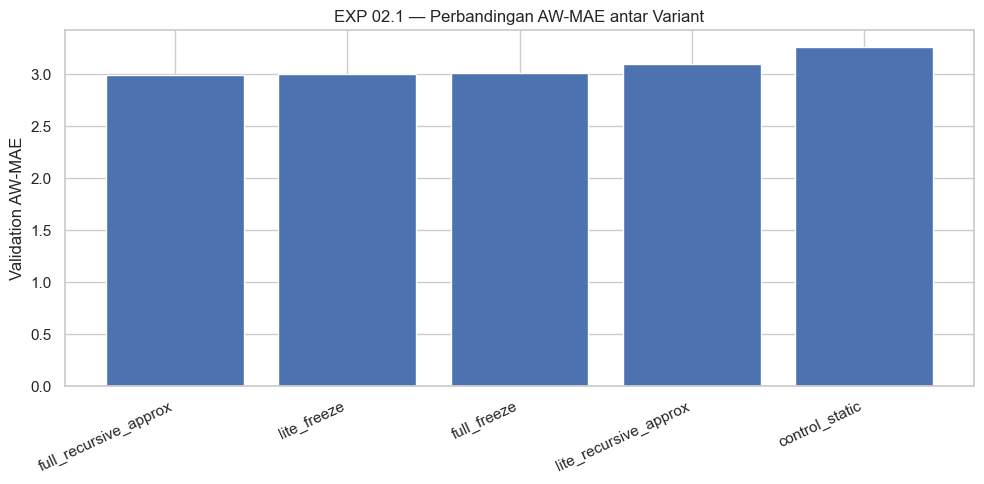

In [21]:

variant_records = [
    {
        "variant_name": "control_static",
        "feature_mode": "static",
        "simulation_mode": "batch",
        "approx_or_faithful": "exact_for_this_variant",
        "valid_awmae": awmae_control,
        "decoder_params": json.dumps(best_params_control),
        "runtime_note": "raw outputs batch + decoder tuning",
    },
    {
        "variant_name": "lite_freeze",
        "feature_mode": "lite",
        "simulation_mode": "freeze",
        "approx_or_faithful": "faithful_for_freeze",
        "valid_awmae": awmae_lite_freeze,
        "decoder_params": json.dumps(best_params_lite_freeze),
        "runtime_note": "raw-output-first; no rerun per combo",
    },
    {
        "variant_name": "full_freeze",
        "feature_mode": "full",
        "simulation_mode": "freeze",
        "approx_or_faithful": "faithful_for_freeze",
        "valid_awmae": awmae_full_freeze,
        "decoder_params": json.dumps(best_params_full_freeze),
        "runtime_note": "raw-output-first; no rerun per combo",
    },
    {
        "variant_name": "lite_recursive_approx",
        "feature_mode": "lite",
        "simulation_mode": "recursive",
        "approx_or_faithful": "approximate",
        "valid_awmae": awmae_lite_recursive_approx,
        "decoder_params": json.dumps(best_params_lite_recursive_approx),
        "runtime_note": "single approximate trajectory + post-hoc tuning",
    },
    {
        "variant_name": "full_recursive_approx",
        "feature_mode": "full",
        "simulation_mode": "recursive",
        "approx_or_faithful": "approximate",
        "valid_awmae": awmae_full_recursive_approx,
        "decoder_params": json.dumps(best_params_full_recursive_approx),
        "runtime_note": "single approximate trajectory + post-hoc tuning",
    },
]

variant_metrics = pd.DataFrame(variant_records).sort_values("valid_awmae").reset_index(drop=True)
display(variant_metrics)
variant_metrics.to_csv(SUM_DIR / "variant_metrics.csv", index=False)

plt.figure(figsize=(10, 5))
plt.bar(variant_metrics["variant_name"], variant_metrics["valid_awmae"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("Validation AW-MAE")
plt.title("EXP 02.1 — Perbandingan AW-MAE antar Variant")
plt.tight_layout()
plt.savefig(FIG_DIR / "awmae_variant_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## 17. Raw Signal Analysis vs Final AW-MAE


In [22]:

def summarize_raw_signal(raw_df: pd.DataFrame, name: str) -> dict:
    outcome_pred = raw_df[["pred_outcome_proba_0", "pred_outcome_proba_1", "pred_outcome_proba_2"]].values.argmax(axis=1)
    outcome_true = build_outcome_target(raw_df["actual_team_a_goals"], raw_df["actual_team_b_goals"]).values
    return {
        "variant": name,
        "outcome_accuracy": accuracy_score(outcome_true, outcome_pred),
        "mae_total_goals": mean_absolute_error(
            raw_df["actual_team_a_goals"] + raw_df["actual_team_b_goals"],
            raw_df["pred_total_cont"],
        ),
        "mae_goal_diff": mean_absolute_error(
            raw_df["actual_team_a_goals"] - raw_df["actual_team_b_goals"],
            raw_df["pred_gd_cont"],
        ),
        "mae_goal_a": mean_absolute_error(raw_df["actual_team_a_goals"], raw_df["pred_goal_a_cont"]),
        "mae_goal_b": mean_absolute_error(raw_df["actual_team_b_goals"], raw_df["pred_goal_b_cont"]),
    }

raw_signal_summary = pd.DataFrame([
    summarize_raw_signal(raw_control, "control_static"),
    summarize_raw_signal(raw_lite_freeze, "lite_freeze"),
    summarize_raw_signal(raw_full_freeze, "full_freeze"),
    summarize_raw_signal(raw_lite_recursive_approx, "lite_recursive_approx"),
    summarize_raw_signal(raw_full_recursive_approx, "full_recursive_approx"),
]).sort_values("variant")

display(raw_signal_summary)


,variant,outcome_accuracy,mae_total_goals,mae_goal_diff,mae_goal_a,mae_goal_b
0,control_static,0.573242,1.578984,1.686227,1.109324,1.137102
2,full_freeze,0.598883,1.565366,1.594323,1.046537,1.084008
4,full_recursive_approx,0.593044,1.532548,1.576051,1.021983,1.076353
1,lite_freeze,0.592536,1.549889,1.599052,1.042749,1.089377
3,lite_recursive_approx,0.589871,1.558674,1.648902,1.055863,1.104571


Section ini dipakai untuk memisahkan dua hal: **sinyal mentah model** vs **kerusakan yang muncul dari simulation atau decoder**. Jadi kalau sebuah variant punya raw signal cukup bagus tapi AW-MAE akhirnya jelek, masalahnya mungkin bukan di model dasar, melainkan di decision layer atau regime evaluasi.


## 18. Feature Importance Shift Analysis


,variant,identity_share
0,control,0.471639
1,lite,0.234413
2,full,0.212367


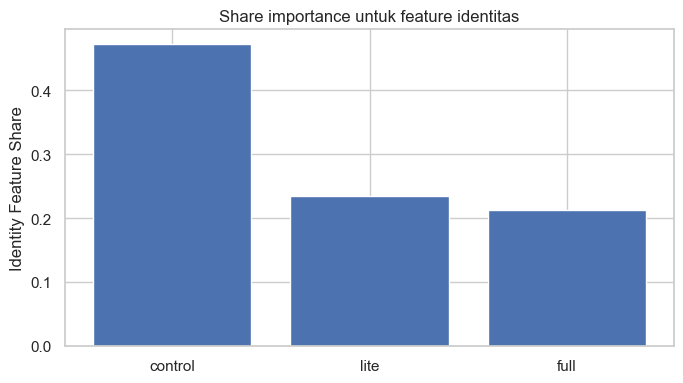

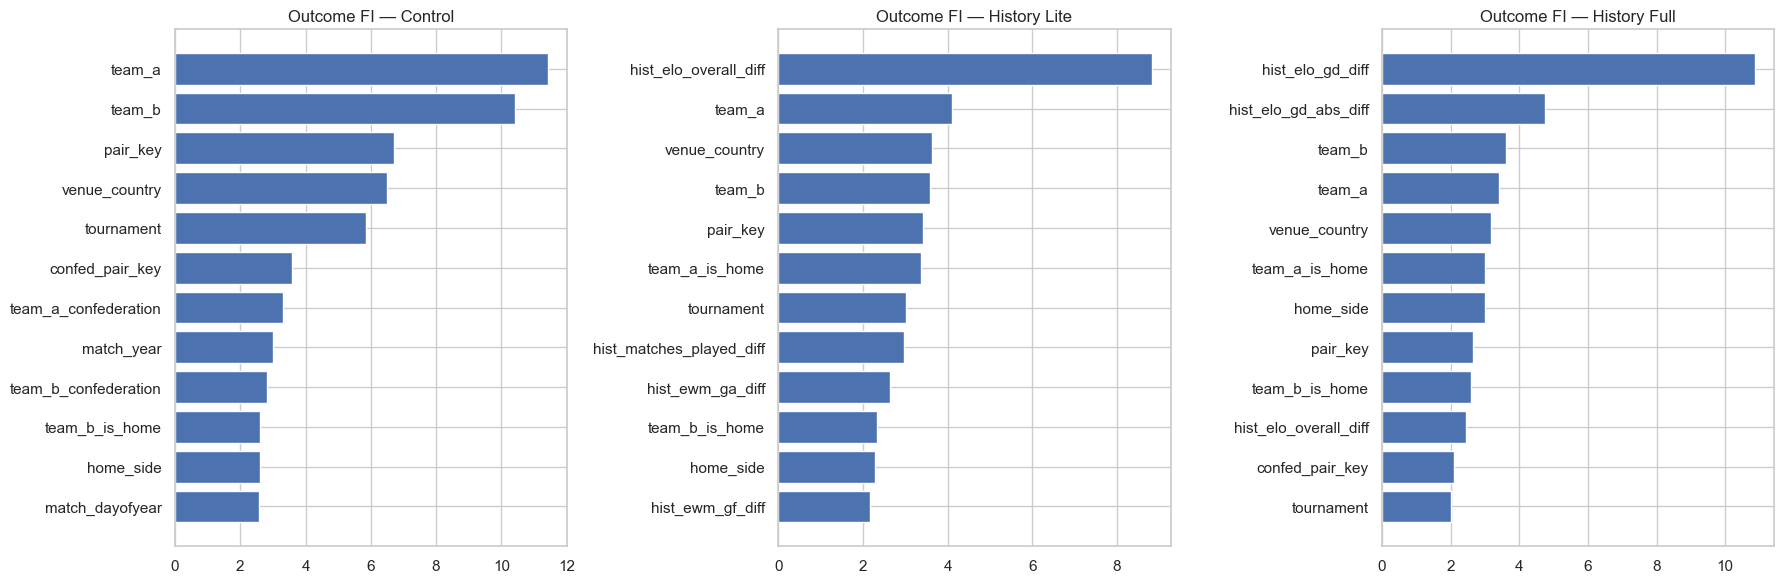

In [23]:

def extract_feature_importance(bundle: dict, model_key: str = "outcome") -> pd.DataFrame:
    feat = bundle["feature_cols"]
    imp = bundle["models"][model_key].get_feature_importance()
    return pd.DataFrame({"feature": feat, "importance": imp}).sort_values("importance", ascending=False)

fi_control = extract_feature_importance(control_bundle, model_key="outcome")
fi_lite = extract_feature_importance(lite_bundle, model_key="outcome")
fi_full = extract_feature_importance(full_bundle, model_key="outcome")

identity_keywords = ["team_a", "team_b", "pair_key", "match_year", "match_decade"]

def identity_share(fi: pd.DataFrame) -> float:
    total = fi["importance"].sum()
    identity = fi.loc[fi["feature"].apply(lambda x: any(k in str(x) for k in identity_keywords)), "importance"].sum()
    return float(identity / total) if total > 0 else np.nan

identity_share_df = pd.DataFrame({
    "variant": ["control", "lite", "full"],
    "identity_share": [identity_share(fi_control), identity_share(fi_lite), identity_share(fi_full)],
})

display(identity_share_df)

plt.figure(figsize=(7, 4))
plt.bar(identity_share_df["variant"], identity_share_df["identity_share"])
plt.ylabel("Identity Feature Share")
plt.title("Share importance untuk feature identitas")
plt.tight_layout()
plt.savefig(FIG_DIR / "identity_share_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, fi, title in zip(axes, [fi_control, fi_lite, fi_full], ["Control", "History Lite", "History Full"]):
    top = fi.head(12)
    ax.barh(top["feature"], top["importance"])
    ax.set_title(f"Outcome FI — {title}")
    ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_importance_outcome_compare.png", dpi=150, bbox_inches="tight")
plt.show()


## 19. Subgroup Error Analysis


,group,n,awmae,variant
0,W,1848,4.383744,control_static
1,M,6030,2.891952,control_static
2,W,1848,3.783196,lite_freeze
3,M,6030,2.754607,lite_freeze
4,W,1848,3.714326,full_freeze
5,M,6030,2.782089,full_freeze
6,W,1848,3.849306,lite_recursive_approx
7,M,6030,2.851319,lite_recursive_approx
8,W,1848,3.691355,full_recursive_approx
9,M,6030,2.770956,full_recursive_approx


,group,n,awmae,variant
0,1,2583,3.765010,control_static
1,0,5295,3.035462,control_static
2,1,2583,3.445874,lite_freeze
3,0,5295,2.813781,lite_freeze
4,1,2583,3.460375,full_freeze
5,0,5295,2.812657,full_freeze
6,1,2583,3.501229,lite_recursive_approx
7,0,5295,2.917994,lite_recursive_approx
8,1,2583,3.415687,full_recursive_approx
9,0,5295,2.812247,full_recursive_approx


,group,n,awmae,variant
0,1,504,6.841738,control_static
1,0,7374,3.004249,control_static
2,1,504,5.970351,lite_freeze
3,0,7374,2.796836,lite_freeze
4,1,504,5.622551,full_freeze
5,0,7374,2.825656,full_freeze
6,1,504,6.372407,lite_recursive_approx
7,0,7374,2.863622,lite_recursive_approx
8,1,504,6.006249,full_recursive_approx
9,0,7374,2.783164,full_recursive_approx


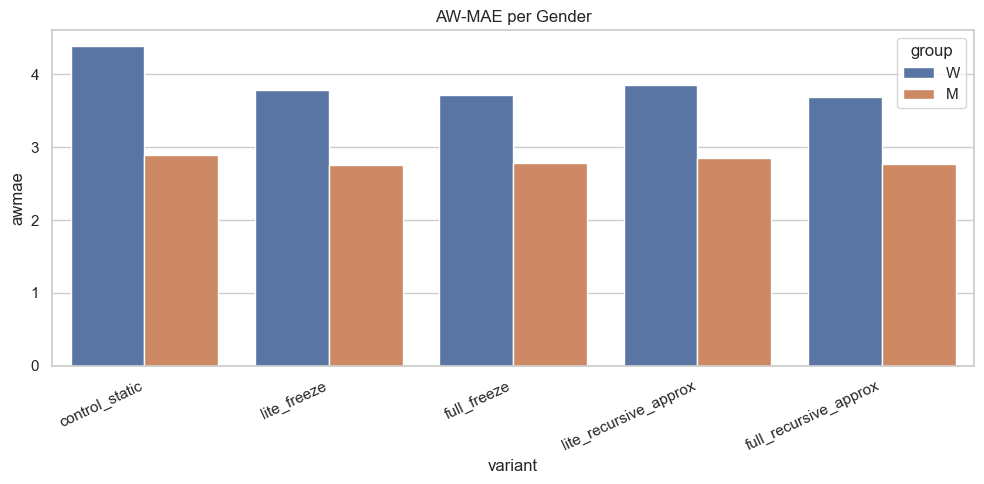

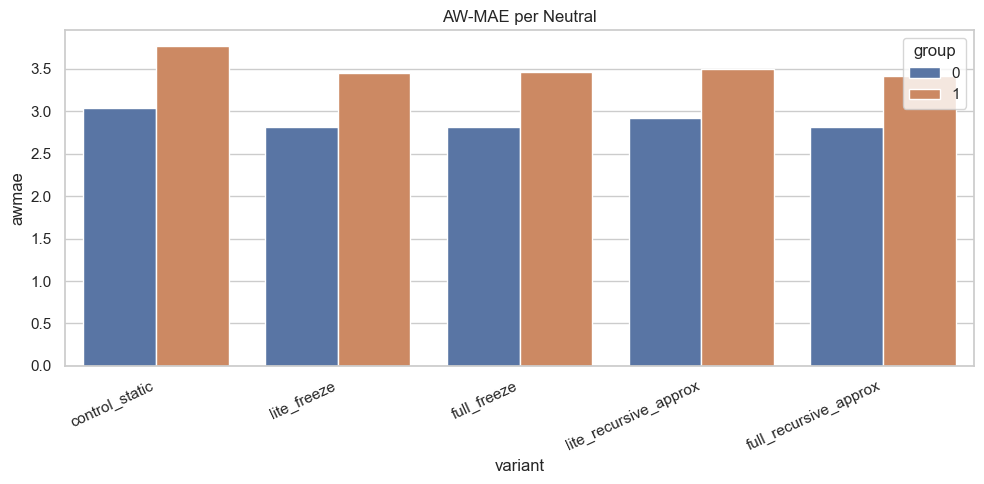

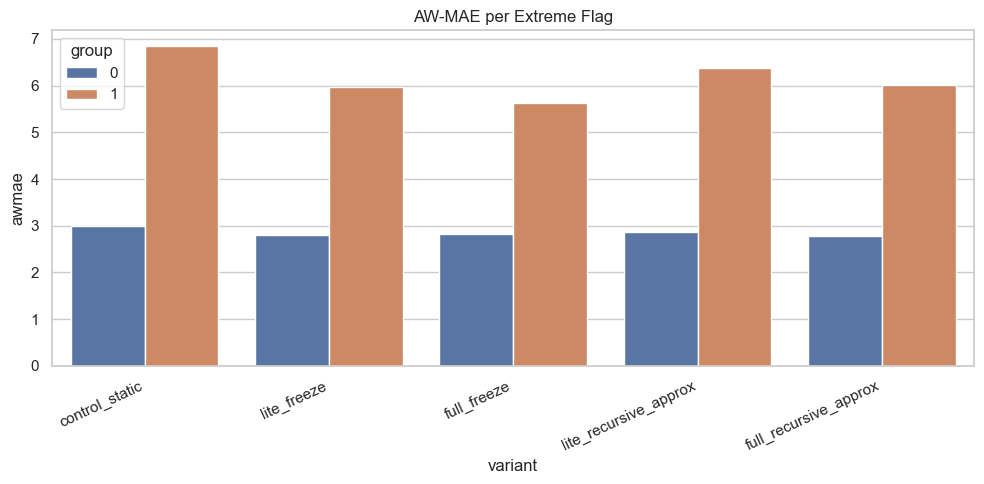

In [25]:

def add_extreme_flag(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["is_extreme_actual"] = (
        np.maximum(df["actual_team_a_goals"], df["actual_team_b_goals"]) >= 6
    ).astype(int)
    return df


def _get_tournament_series(df: pd.DataFrame) -> pd.Series:
    """Ambil kolom tournament dari nama yang paling stabil di hasil merge."""
    for col in ["tournament", "tournament_x", "tournament_y", "tournament_base"]:
        if col in df.columns:
            return df[col]
    raise KeyError("Kolom tournament tidak ditemukan di dataframe subgroup.")


def subgroup_awmae(pred_df: pd.DataFrame, group_col: str, top_n: int = 10) -> pd.DataFrame:
    temp = pred_df.copy()
    temp = add_extreme_flag(temp)
    rows = []
    for name, grp in temp.groupby(group_col):
        if len(grp) < 3:
            continue
        score = awmae_score(
            grp["actual_team_a_goals"], grp["actual_team_b_goals"],
            grp["pred_team_a_goals"], grp["pred_team_b_goals"],
            _get_tournament_series(grp),
        )
        rows.append({"group": name, "n": len(grp), "awmae": score})
    out = pd.DataFrame(rows).sort_values("awmae", ascending=False).head(top_n)
    return out


variant_pred_map = {
    "control_static": valid_pred_match_control,
    "lite_freeze": valid_pred_match_lite_freeze,
    "full_freeze": valid_pred_match_full_freeze,
    "lite_recursive_approx": valid_pred_match_lite_recursive_approx,
    "full_recursive_approx": valid_pred_match_full_recursive_approx,
}

# Tambah subgroup columns dari valid_fold_base
base_cols = valid_fold_base[["match_id", "gender", "neutral", "tournament"]].copy()
for name in list(variant_pred_map):
    variant_pred_map[name] = variant_pred_map[name].merge(base_cols, on="match_id", how="left", suffixes=("", "_base"))

# Gender
rows_gender = []
rows_neutral = []
rows_extreme = []
for name, dfp in variant_pred_map.items():
    for g in subgroup_awmae(dfp, "gender").to_dict("records"):
        g["variant"] = name
        rows_gender.append(g)
    for g in subgroup_awmae(dfp, "neutral").to_dict("records"):
        g["variant"] = name
        rows_neutral.append(g)
    ext_df = add_extreme_flag(dfp)
    for g in subgroup_awmae(ext_df, "is_extreme_actual").to_dict("records"):
        g["variant"] = name
        rows_extreme.append(g)

subgroup_gender_df = pd.DataFrame(rows_gender)
subgroup_neutral_df = pd.DataFrame(rows_neutral)
subgroup_extreme_df = pd.DataFrame(rows_extreme)

display(subgroup_gender_df)
display(subgroup_neutral_df)
display(subgroup_extreme_df)

for df_plot, title, fname in [
    (subgroup_gender_df, "AW-MAE per Gender", "subgroup_awmae_gender.png"),
    (subgroup_neutral_df, "AW-MAE per Neutral", "subgroup_awmae_neutral.png"),
    (subgroup_extreme_df, "AW-MAE per Extreme Flag", "subgroup_awmae_extreme.png"),
]:
    plt.figure(figsize=(10, 5))
    if not df_plot.empty:
        sns.barplot(data=df_plot, x="variant", y="awmae", hue="group")
        plt.xticks(rotation=25, ha="right")
        plt.title(title)
        plt.tight_layout()
        plt.savefig(FIG_DIR / fname, dpi=150, bbox_inches="tight")
        plt.show()


## 20. Keputusan Eksperimen


In [26]:

best_row = variant_metrics.iloc[0].to_dict()
best_variant_name = best_row["variant_name"]
best_valid_awmae = float(best_row["valid_awmae"])

if best_variant_name == "control_static":
    experiment_decision = "C — History branch tetap kalah dari control dan tidak layak diprioritaskan."
elif "lite" in best_variant_name:
    experiment_decision = "A — History-lite membantu dan layak diteruskan."
else:
    experiment_decision = "B — History-full membantu, history-lite tidak cukup."

print("=" * 80)
print("KEPUTUSAN FINAL EXP 02.1")
print("=" * 80)
print(f"Best variant     : {best_variant_name}")
print(f"Best valid AW-MAE: {best_valid_awmae:.6f}")
print(f"Decision         : {experiment_decision}")


KEPUTUSAN FINAL EXP 02.1
Best variant     : full_recursive_approx
Best valid AW-MAE: 2.998211
Decision         : B — History-full membantu, history-lite tidak cukup.


## 21. Retrain Best Variant pada Full Train


In [27]:

# Full-train target construction
train_full_static = train_static_df.copy()
train_full_static["y_goal_a"] = train_match_base["team_a_goals"].values
train_full_static["y_goal_b"] = train_match_base["team_b_goals"].values
train_full_static["y_total_goals"] = train_match_base["team_a_goals"].values + train_match_base["team_b_goals"].values
train_full_static["y_goal_diff"] = train_match_base["team_a_goals"].values - train_match_base["team_b_goals"].values
train_full_static["y_outcome_class"] = build_outcome_target(train_match_base["team_a_goals"], train_match_base["team_b_goals"]).values

train_full_hist_lite, cutoff_team_states_test_lite, cutoff_h2h_states_test_lite = build_train_history_features(train_match_base, feature_mode="lite")
train_full_hist_full, cutoff_team_states_test_full, cutoff_h2h_states_test_full = build_train_history_features(train_match_base, feature_mode="full")

train_full_lite = train_full_static.merge(train_full_hist_lite, on="match_id", how="left")
train_full_full = train_full_static.merge(train_full_hist_full, on="match_id", how="left")

if best_variant_name == "control_static":
    best_bundle_full = fit_model_bundle(train_full_static, control_features, static_categorical_features, tag="full_control")
    best_feature_mode = "static"
    best_decoder_params = best_params_control
elif best_variant_name == "lite_freeze":
    best_bundle_full = fit_model_bundle(train_full_lite, lite_features, static_categorical_features, tag="full_lite")
    best_feature_mode = "lite"
    best_decoder_params = best_params_lite_freeze
elif best_variant_name == "full_freeze":
    best_bundle_full = fit_model_bundle(train_full_full, full_features, static_categorical_features, tag="full_full")
    best_feature_mode = "full"
    best_decoder_params = best_params_full_freeze
elif best_variant_name == "lite_recursive_approx":
    best_bundle_full = fit_model_bundle(train_full_lite, lite_features, static_categorical_features, tag="full_lite")
    best_feature_mode = "lite"
    best_decoder_params = best_params_lite_recursive_approx
else:
    best_bundle_full = fit_model_bundle(train_full_full, full_features, static_categorical_features, tag="full_full")
    best_feature_mode = "full"
    best_decoder_params = best_params_full_recursive_approx

print(f"[INFO] Best variant retrained: {best_variant_name}")
print(f"[INFO] Best feature mode    : {best_feature_mode}")
print(f"[INFO] Best decoder params  : {best_decoder_params}")


build_train_history[lite]:   0%|          | 0/39386 [00:00<?, ?it/s]

build_train_history[full]:   0%|          | 0/39386 [00:00<?, ?it/s]

[INFO] full_full: inner_train=(33478, 130), inner_eval=(5908, 130)
[INFO] Fitting full_full:goal_a
0:	learn: 1.7851535	test: 1.6085773	best: 1.6085773 (0)	total: 104ms	remaining: 2m 35s
200:	learn: 1.3887064	test: 1.3080704	best: 1.3077639 (187)	total: 23.2s	remaining: 2m 29s
400:	learn: 1.3342572	test: 1.3032050	best: 1.3031551 (395)	total: 46.4s	remaining: 2m 7s
600:	learn: 1.2957287	test: 1.3033885	best: 1.3028765 (476)	total: 1m 25s	remaining: 2m 8s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 1.302876497
bestIteration = 476

Shrink model to first 477 iterations.
[INFO] Fitting full_full:goal_b
0:	learn: 1.7765572	test: 1.9072748	best: 1.9072748 (0)	total: 189ms	remaining: 4m 42s
200:	learn: 1.3936551	test: 1.4966630	best: 1.4966630 (200)	total: 27.5s	remaining: 2m 57s
400:	learn: 1.3575135	test: 1.4875493	best: 1.4873760 (394)	total: 47.1s	remaining: 2m 9s
600:	learn: 1.3260259	test: 1.4854344	best: 1.4852640 (551)	total: 1m 8s	remaining: 1m 42s
800:	learn: 1

## 22. Test Inference


In [28]:

def _build_test_static_df(base_match_df: pd.DataFrame, static_df: pd.DataFrame) -> pd.DataFrame:
    return static_df.sort_values(["date", "match_id"]).reset_index(drop=True).copy()


test_static_ready = _build_test_static_df(test_match_base, test_static_df)
scoreline_prior_test = build_scoreline_prior(
    train_match_base["team_a_goals"], train_match_base["team_b_goals"], best_decoder_params["MAX_GOALS"], alpha=1.0
)

if best_variant_name == "control_static":
    raw_test_best = predict_raw_outputs_for_df(test_static_ready, best_bundle_full)
    pred_test_best = decode_batch_scores(raw_test_best, best_decoder_params, scoreline_prior_test)
    test_pred_match_best = raw_test_best.merge(pred_test_best, on="match_id", how="left")

elif best_variant_name in ["lite_freeze", "full_freeze"]:
    if best_feature_mode == "lite":
        cutoff_team_states_test = cutoff_team_states_test_lite
        cutoff_h2h_states_test = cutoff_h2h_states_test_lite
    else:
        cutoff_team_states_test = cutoff_team_states_test_full
        cutoff_h2h_states_test = cutoff_h2h_states_test_full

    raw_test_best = simulate_freeze_raw_outputs(
        test_match_base,
        test_static_ready,
        cutoff_team_states_test,
        cutoff_h2h_states_test,
        best_bundle_full,
        feature_mode=best_feature_mode,
    )
    pred_test_best = decode_batch_scores(raw_test_best, best_decoder_params, scoreline_prior_test)
    test_pred_match_best = raw_test_best.merge(pred_test_best, on="match_id", how="left")

else:
    if best_feature_mode == "lite":
        cutoff_team_states_test = cutoff_team_states_test_lite
        cutoff_h2h_states_test = cutoff_h2h_states_test_lite
    else:
        cutoff_team_states_test = cutoff_team_states_test_full
        cutoff_h2h_states_test = cutoff_h2h_states_test_full

    raw_test_best, pred_test_best = simulate_recursive_approx(
        test_match_base,
        test_static_ready,
        cutoff_team_states_test,
        cutoff_h2h_states_test,
        best_bundle_full,
        best_decoder_params,
        scoreline_prior_test,
        feature_mode=best_feature_mode,
    )
    test_pred_match_best = raw_test_best.merge(pred_test_best, on="match_id", how="left")

# rapikan minimal output
keep_cols = ["match_id", "team_a", "team_b", "pred_team_a_goals", "pred_team_b_goals"]
if "team_a" not in test_pred_match_best.columns or "team_b" not in test_pred_match_best.columns:
    test_pred_match_best = test_pred_match_best.merge(test_match_base[["match_id", "team_a", "team_b"]], on="match_id", how="left")

test_pred_match_best = test_pred_match_best[keep_cols].copy()
test_pred_match_best.to_csv(PRED_DIR / "test_pred_match_best.csv", index=False)
print(f"[OK] test_pred_match_best shape = {test_pred_match_best.shape}")
display(test_pred_match_best.head())


recursive_approx[full]:   0%|          | 0/21211 [00:00<?, ?it/s]

[OK] test_pred_match_best shape = (21211, 5)


,match_id,team_a,team_b,pred_team_a_goals,pred_team_b_goals
0,M034984,Mauritius,Seychelles,1,2
1,M034985,Comoros,Maldives,1,2
2,M034986,Madagascar,Réunion,1,2
3,M034987,El Salvador,Venezuela,1,2
4,M034988,Mayotte,Réunion,1,2


## 23. Reverse Mapping ke Submission


In [29]:

submission = match_predictions_to_submission(test, test_pred_match_best)

assert len(submission) == len(sample_sub), "Jumlah row submission tidak sama dengan sample submission."
assert (submission["Id"].values == sample_sub["Id"].values).all(), "Urutan Id tidak sama dengan sample submission."
assert list(submission.columns) == ["Id", "team_goals", "opp_goals"], "Format kolom submission salah."
assert submission["team_goals"].notna().all(), "Masih ada missing team_goals di submission."
assert submission["opp_goals"].notna().all(), "Masih ada missing opp_goals di submission."

submission["team_goals"] = submission["team_goals"].astype(int)
submission["opp_goals"] = submission["opp_goals"].astype(int)
submission.to_csv(SUB_DIR / "submission_exp02_1_best.csv", index=False)

print(f"[OK] submission shape = {submission.shape}")
display(submission.head())


[OK] submission shape = (42422, 3)


,Id,team_goals,opp_goals
0,M034984_Seychelles,2,1
1,M034984_Mauritius,1,2
2,M034985_Comoros,1,2
3,M034985_Maldives,2,1
4,M034986_Réunion,2,1


## 24. Ringkasan Hasil Eksperimen


In [30]:

experiment_notes = []
experiment_notes.append("EXP 02.1 — Fair rebuild untuk history branch")
experiment_notes.append(f"Best variant: {best_variant_name}")
experiment_notes.append(f"Best valid AW-MAE: {best_valid_awmae:.6f}")
experiment_notes.append(f"Decision: {experiment_decision}")
experiment_notes.append(f"Control AW-MAE: {awmae_control:.6f}")
experiment_notes.append(f"Lite freeze AW-MAE: {awmae_lite_freeze:.6f}")
experiment_notes.append(f"Full freeze AW-MAE: {awmae_full_freeze:.6f}")
experiment_notes.append(f"Lite recursive approx AW-MAE: {awmae_lite_recursive_approx:.6f}")
experiment_notes.append(f"Full recursive approx AW-MAE: {awmae_full_recursive_approx:.6f}")

with open(SUM_DIR / "experiment_notes.txt", "w", encoding="utf-8") as fp:
    fp.write("\n".join(experiment_notes))

print("\n".join(experiment_notes))


EXP 02.1 — Fair rebuild untuk history branch
Best variant: full_recursive_approx
Best valid AW-MAE: 2.998211
Decision: B — History-full membantu, history-lite tidak cukup.
Control AW-MAE: 3.260289
Lite freeze AW-MAE: 3.008575
Full freeze AW-MAE: 3.012266
Lite recursive approx AW-MAE: 3.097731
Full recursive approx AW-MAE: 2.998211


### Ringkasan objektif

- Notebook ini membersihkan evaluasi history branch agar **freeze** dan **recursive approx** tidak lagi tercampur secara tidak adil.
- **History-lite** dan **history-full** dipisahkan dengan jelas agar bisa diuji apakah block history sederhana justru lebih stabil.
- Eksperimen ini harus berakhir dengan keputusan tegas:
  - **lanjut history branch**, jika lite/full menang secara fair atas control,
  - atau **stop history branch**, jika control tetap dominan.

### Arah berikutnya

- Jika history branch menang, langkah berikutnya lebih masuk akal ke arah **probabilistic / distributional score modeling**.
- Jika history branch kalah, lebih masuk akal berpindah ke branch **distillation / train-only signal transfer** yang tetap legal terhadap setup kompetisi.
